In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [29]:
train = pd.read_csv("DATA\\train.csv")
test = pd.read_csv("DATA\\test.csv")

In [30]:
print(f"train shape: ", train.shape,f"Test shape: ", test.shape)
train.head()

train shape:  (1460, 81) Test shape:  (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [31]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [32]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [33]:
train.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

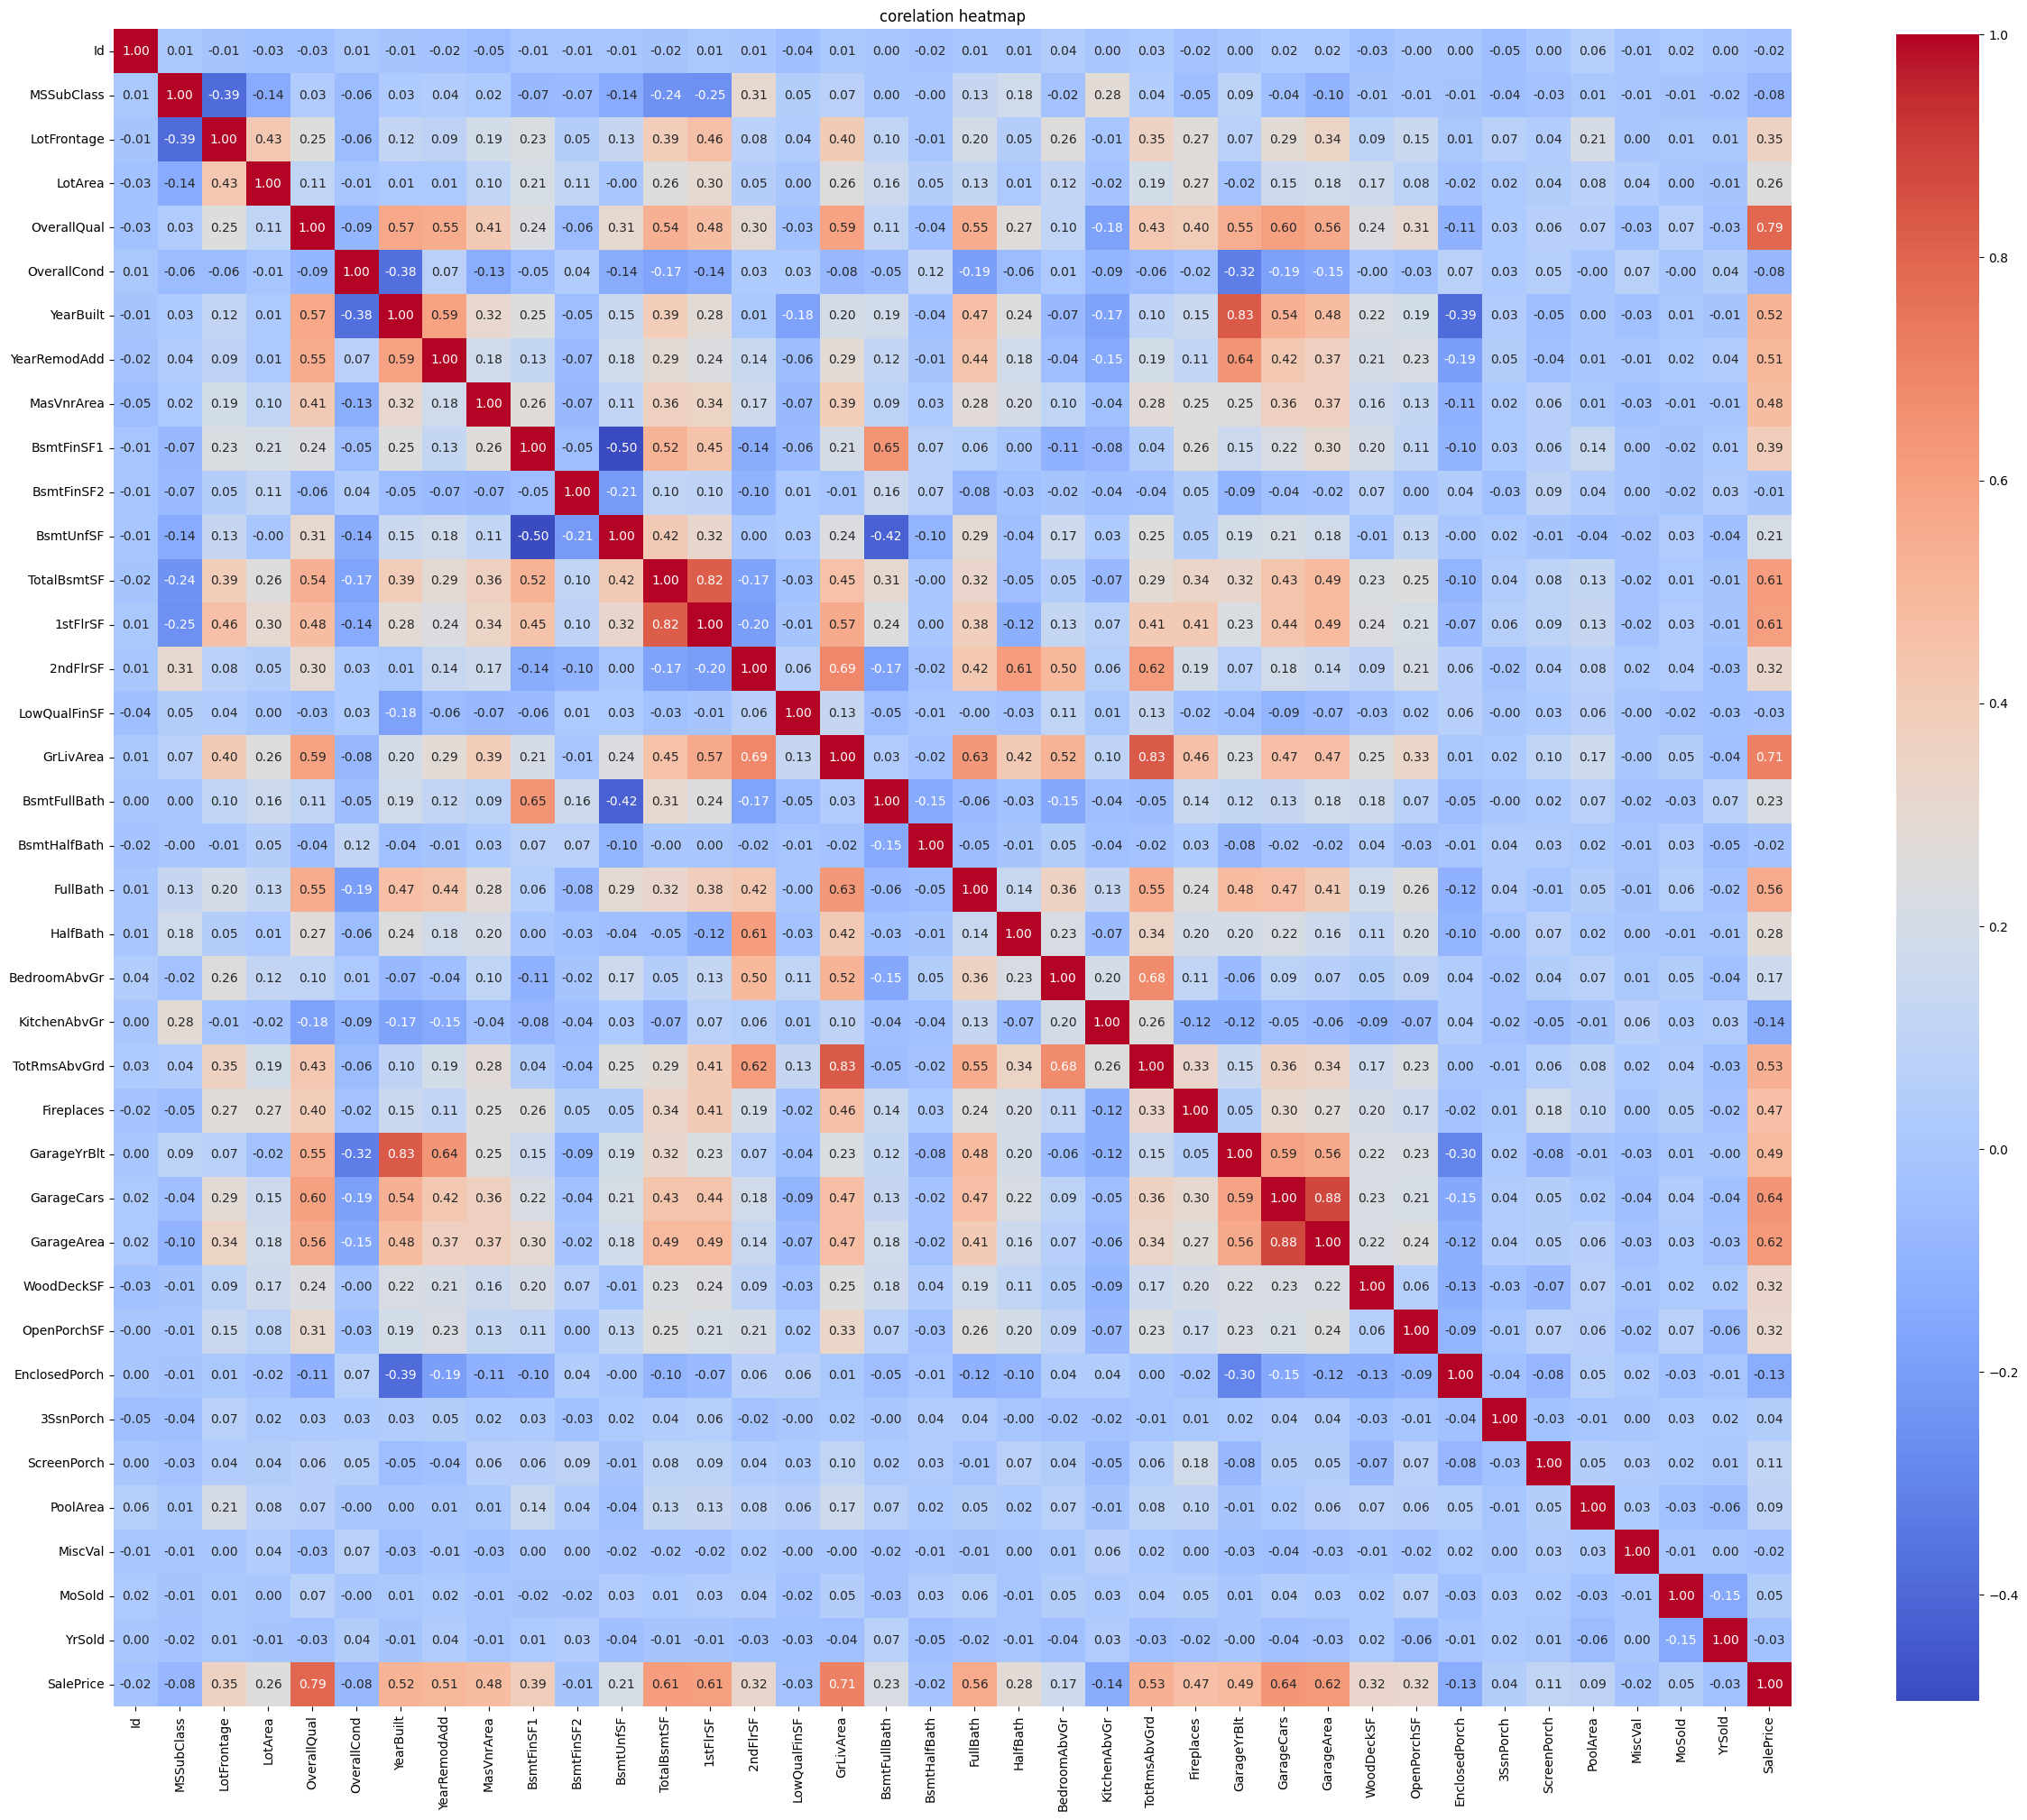

In [34]:
corr = train.corr(numeric_only=True)
plt.figure(figsize=(30,30))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("corelation heatmap")
plt.show()

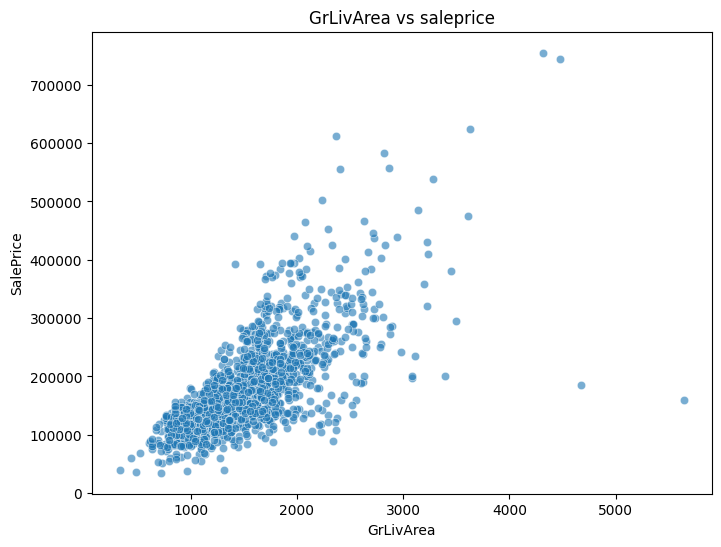

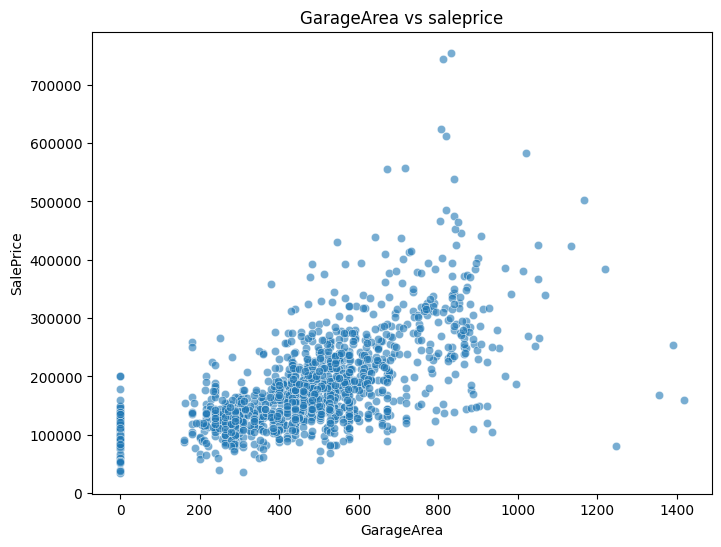

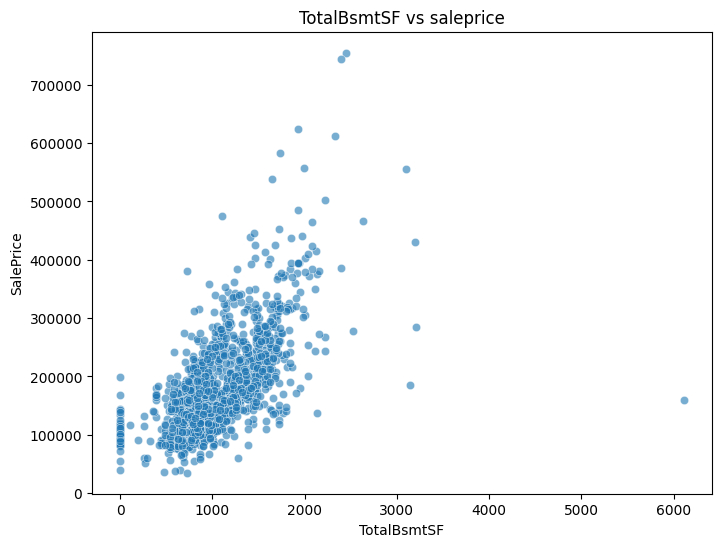

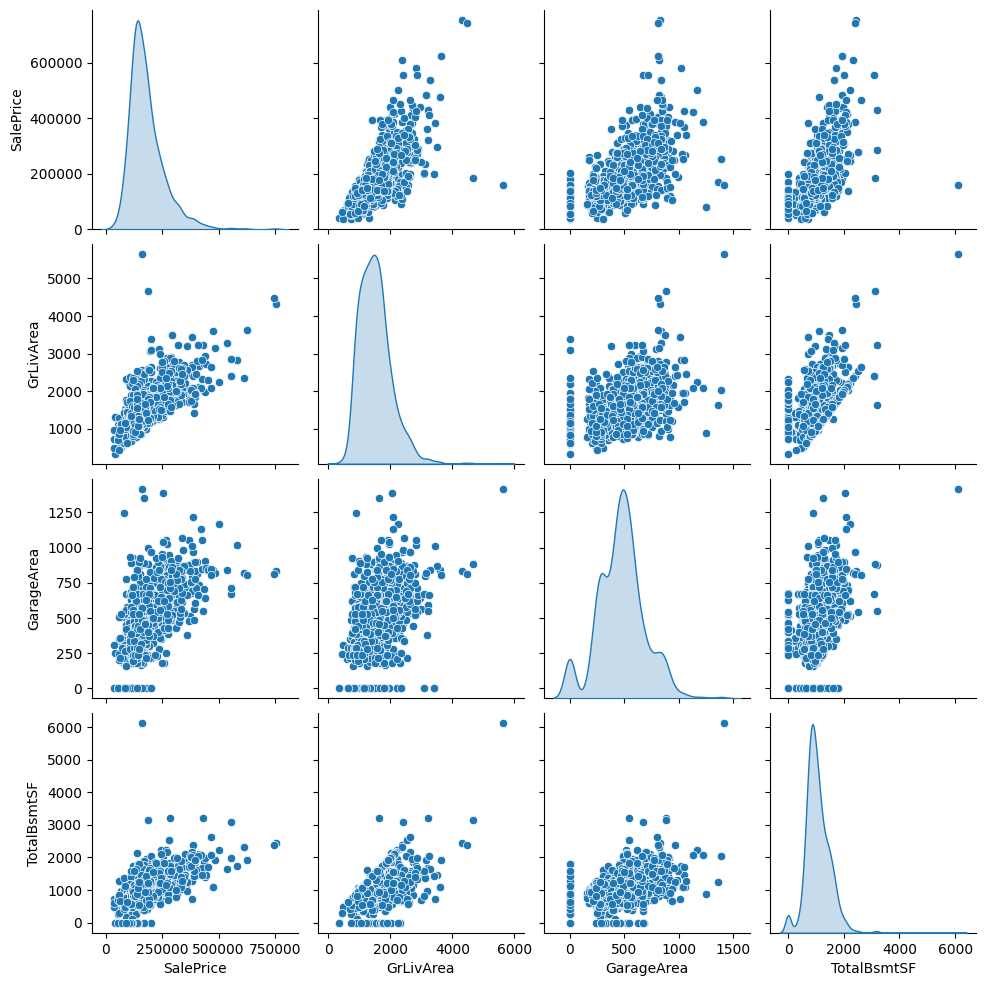

In [35]:
for col in ["GrLivArea", "GarageArea", "TotalBsmtSF"]:
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=train, x=col, y="SalePrice", alpha=0.6)
    plt.title(f"{col} vs saleprice")
    plt.show()

# Pairplot: çoklu değişken ilişkilerini tek seferde görmek
sns.pairplot(train[["SalePrice", "GrLivArea", "GarageArea", "TotalBsmtSF"]], diag_kind="kde")
plt.show()

In [36]:
missing_df = pd.DataFrame({
    'Missing_Values (%)': train.isnull().mean() * 100
}).query("`Missing_Values (%)` > 0").sort_values(by='Missing_Values (%)', ascending=False)
missing_df.round(2)

,Missing_Values (%)
PoolQC,99.52
MiscFeature,96.30
Alley,93.77
Fence,80.75
MasVnrType,59.73
FireplaceQu,47.26
LotFrontage,17.74
GarageType,5.55
GarageYrBlt,5.55
GarageFinish,5.55


In [37]:
missing_df = pd.DataFrame({
    'Missing_Values (%)': test.isnull().mean() * 100
}).query("`Missing_Values (%)` > 0").sort_values(by='Missing_Values (%)', ascending=False)
missing_df.round(2)

,Missing_Values (%)
PoolQC,99.79
MiscFeature,96.50
Alley,92.67
Fence,80.12
MasVnrType,61.27
FireplaceQu,50.03
LotFrontage,15.56
GarageQual,5.35
GarageCond,5.35
GarageYrBlt,5.35


In [38]:
missing = train.isnull().sum()

for col in train.columns:
    if missing[col] > 0:
        print(f'{col} : {missing[col]} {train[col].dtypes}') 

LotFrontage : 259 float64
Alley : 1369 object
MasVnrType : 872 object
MasVnrArea : 8 float64
BsmtQual : 37 object
BsmtCond : 37 object
BsmtExposure : 38 object
BsmtFinType1 : 37 object
BsmtFinType2 : 38 object
Electrical : 1 object
FireplaceQu : 690 object
GarageType : 81 object
GarageYrBlt : 81 float64
GarageFinish : 81 object
GarageQual : 81 object
GarageCond : 81 object
PoolQC : 1453 object
Fence : 1179 object
MiscFeature : 1406 object


In [39]:
missing = test.isnull().sum()

for col in test.columns:
    if missing[col] > 0:
        print(f'{col} : {missing[col]} {test[col].dtypes}') 

MSZoning : 4 object
LotFrontage : 227 float64
Alley : 1352 object
Utilities : 2 object
Exterior1st : 1 object
Exterior2nd : 1 object
MasVnrType : 894 object
MasVnrArea : 15 float64
BsmtQual : 44 object
BsmtCond : 45 object
BsmtExposure : 44 object
BsmtFinType1 : 42 object
BsmtFinSF1 : 1 float64
BsmtFinType2 : 42 object
BsmtFinSF2 : 1 float64
BsmtUnfSF : 1 float64
TotalBsmtSF : 1 float64
BsmtFullBath : 2 float64
BsmtHalfBath : 2 float64
KitchenQual : 1 object
Functional : 2 object
FireplaceQu : 730 object
GarageType : 76 object
GarageYrBlt : 78 float64
GarageFinish : 78 object
GarageCars : 1 float64
GarageArea : 1 float64
GarageQual : 78 object
GarageCond : 78 object
PoolQC : 1456 object
Fence : 1169 object
MiscFeature : 1408 object
SaleType : 1 object


<Axes: >

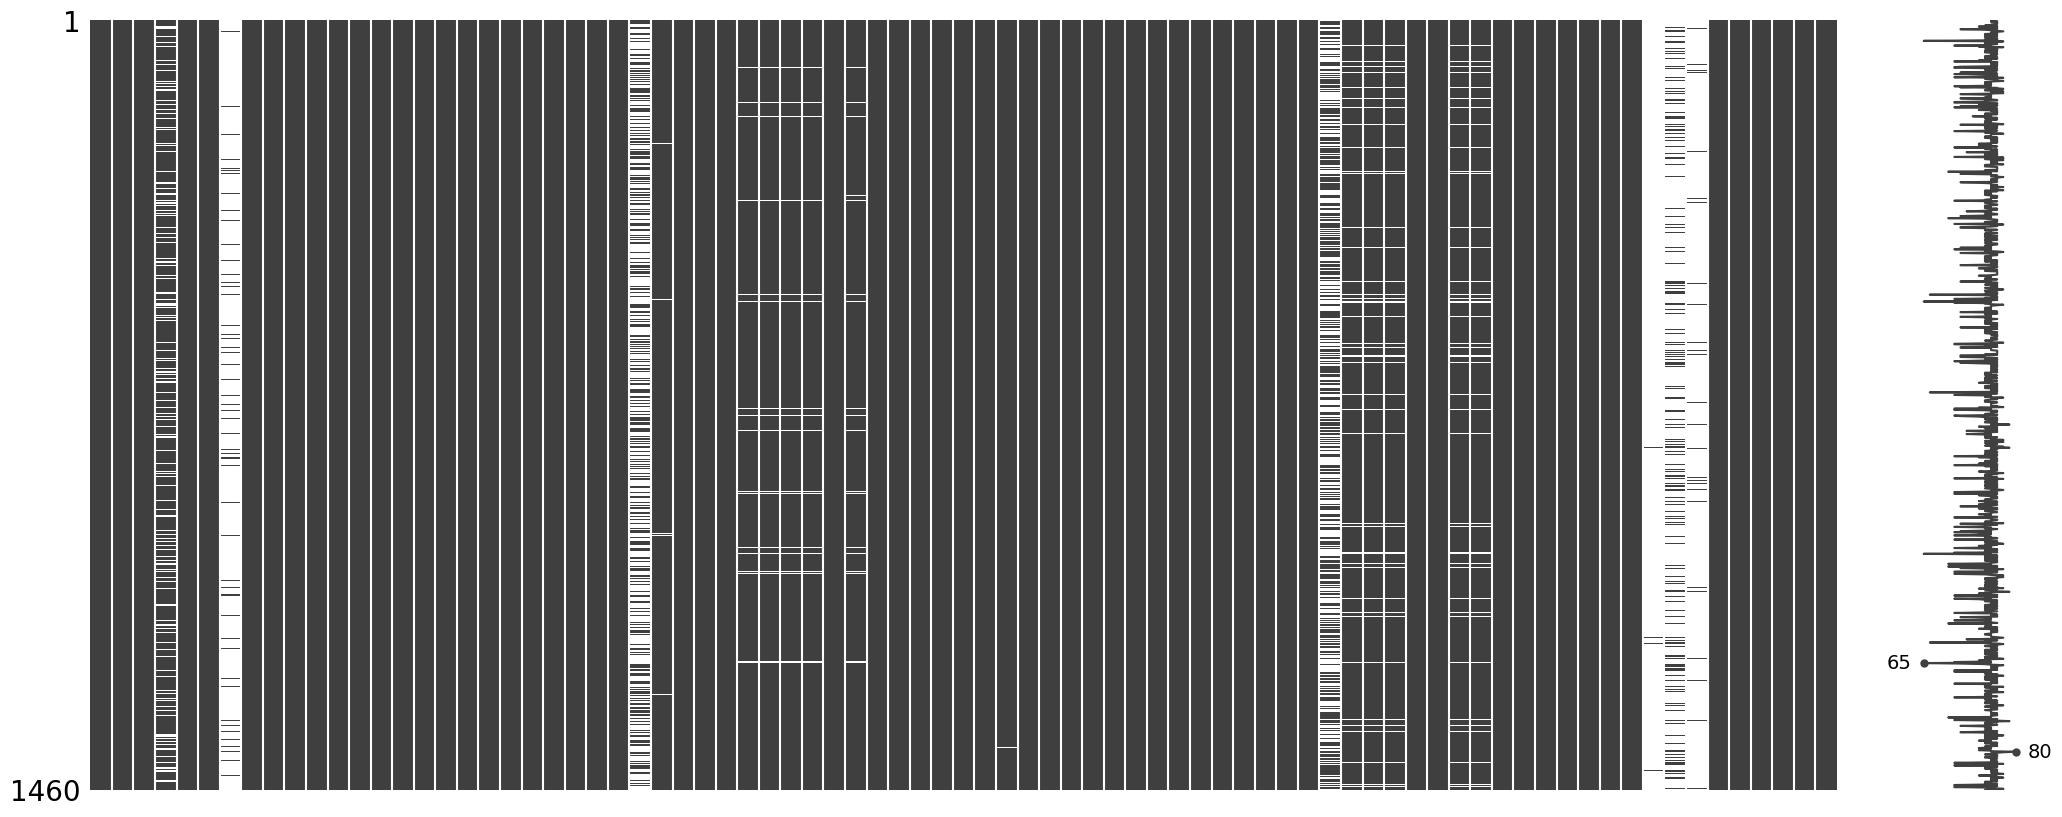

In [40]:
msno.matrix(train)

<Axes: >

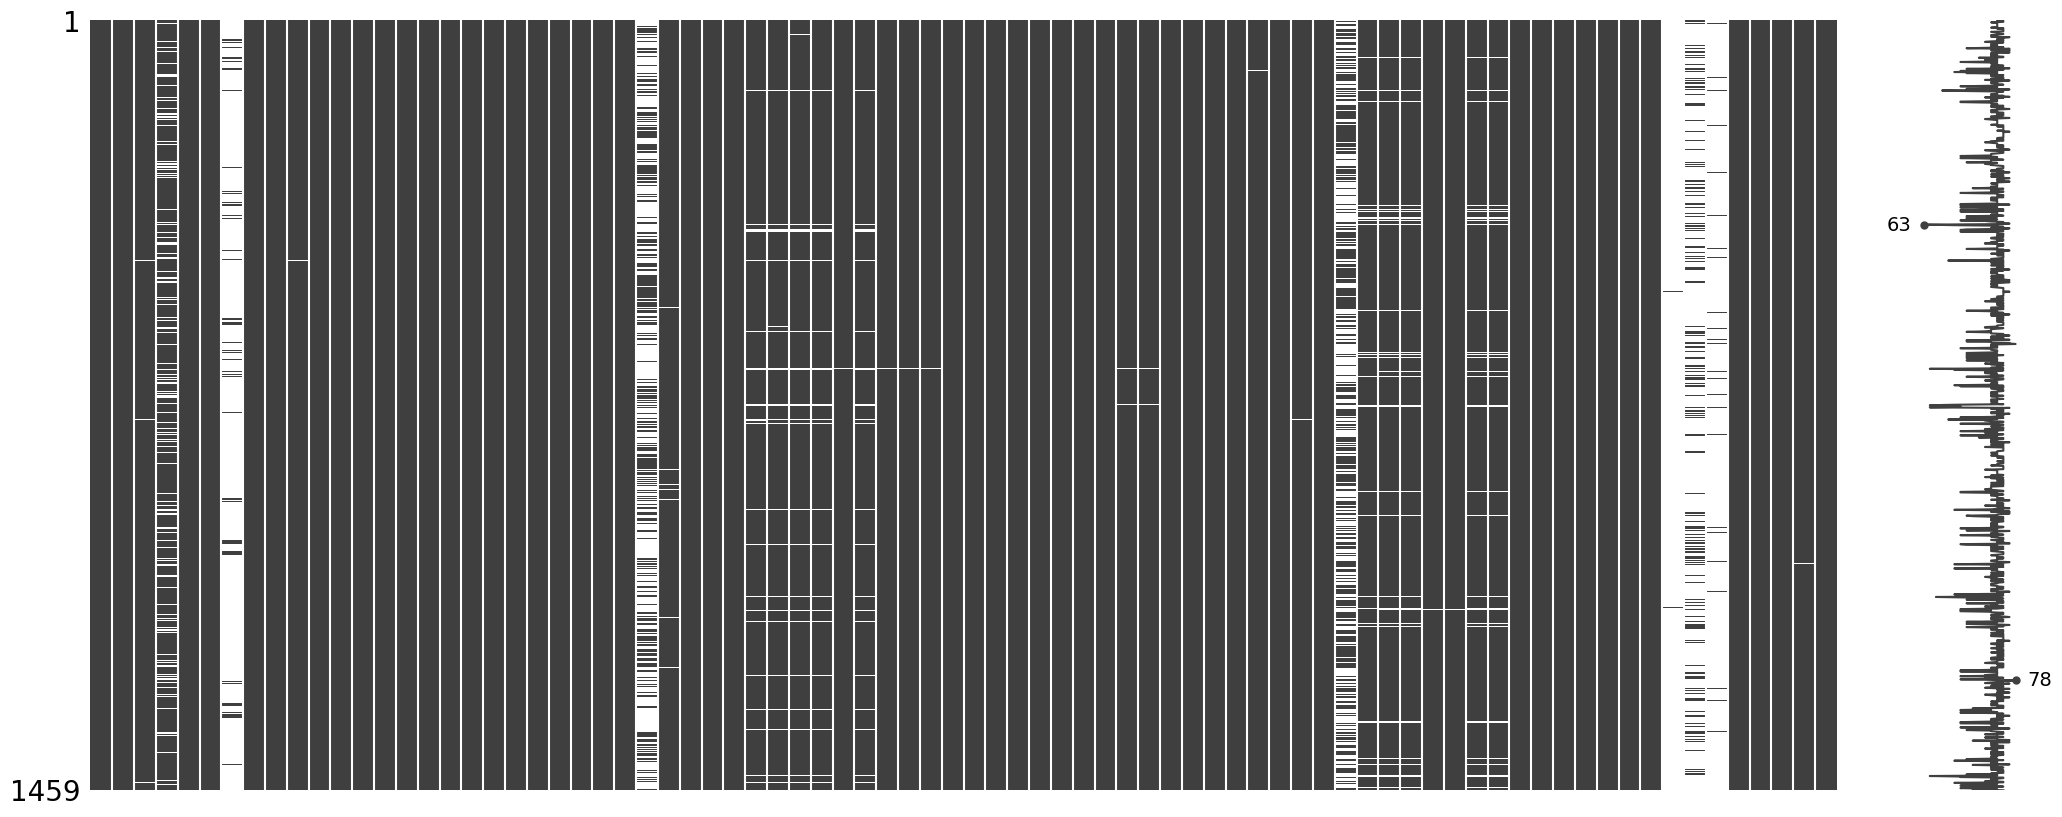

In [41]:
msno.matrix(test)

# **Veri setini düzenleme**

In [42]:
train_id = train['Id']
test_id = test['Id']
y = np.log1p(train['SalePrice'])
train = train.drop(columns=['Id', 'SalePrice'])
test = test.drop(columns=['Id'])

In [43]:
num_cols = train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = train.select_dtypes(include=['object', 'category']).columns

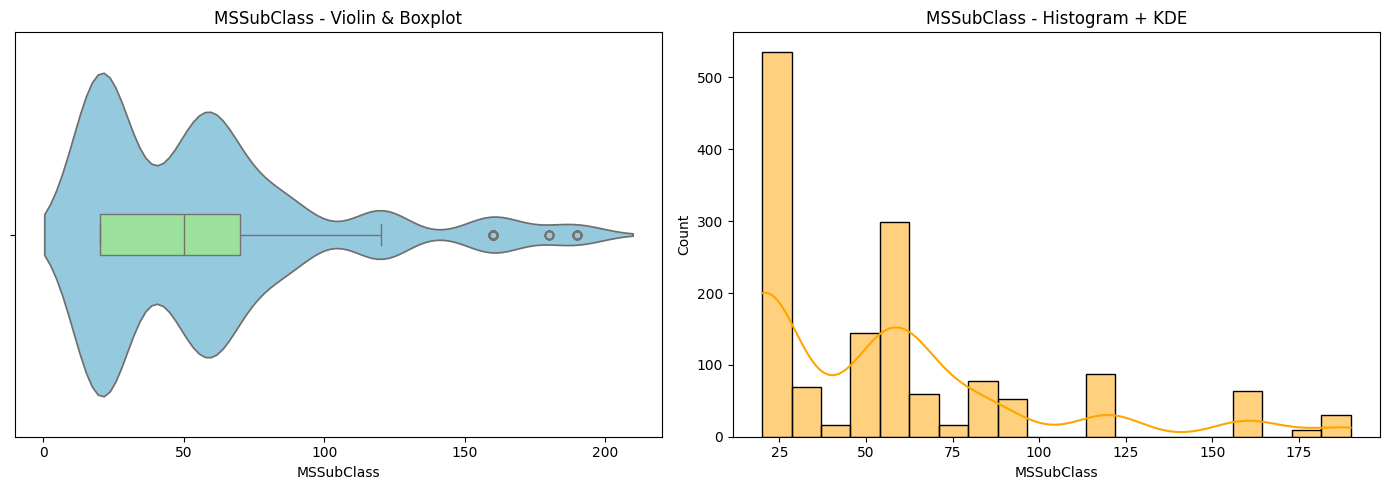

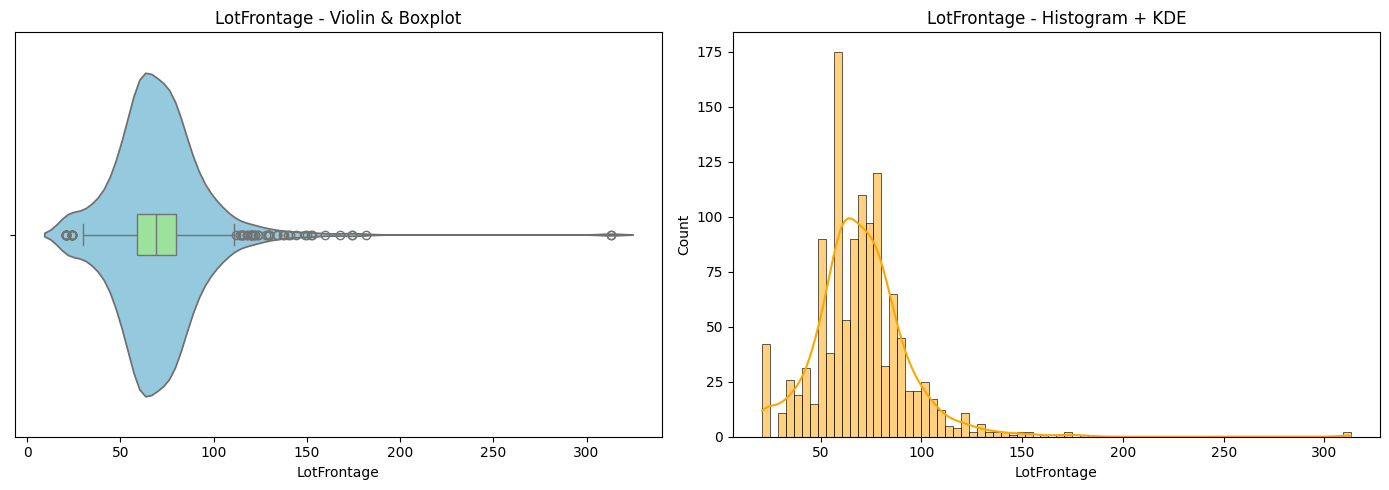

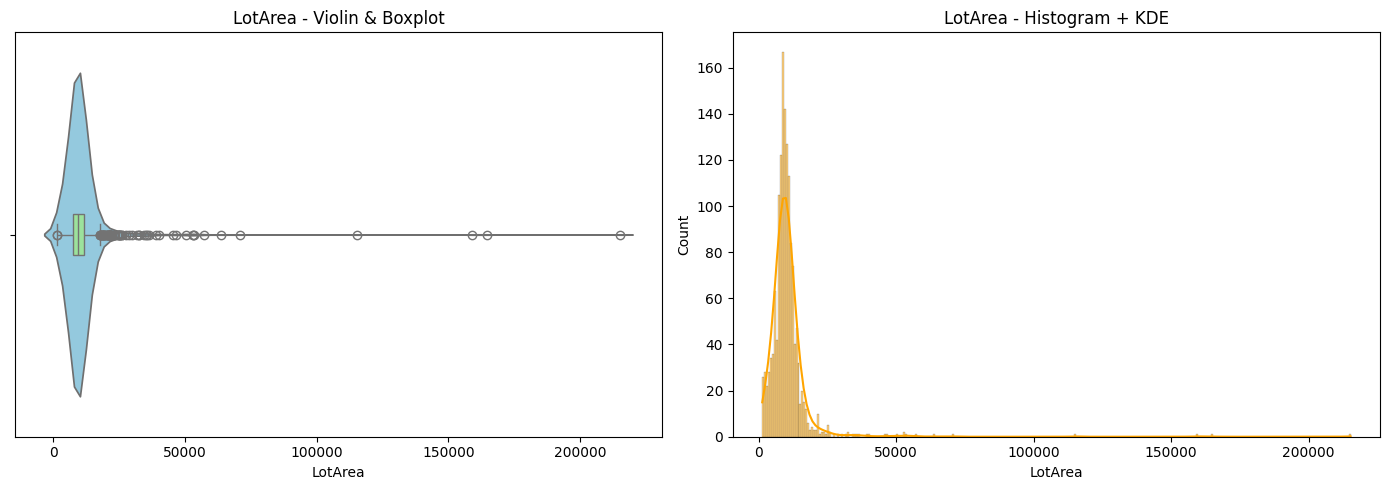

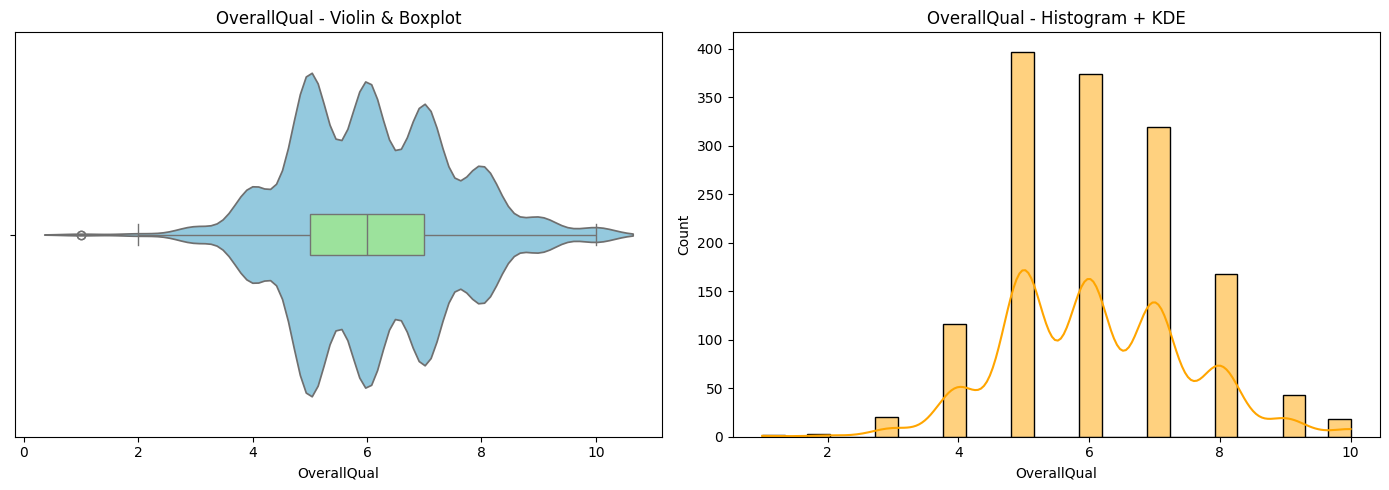

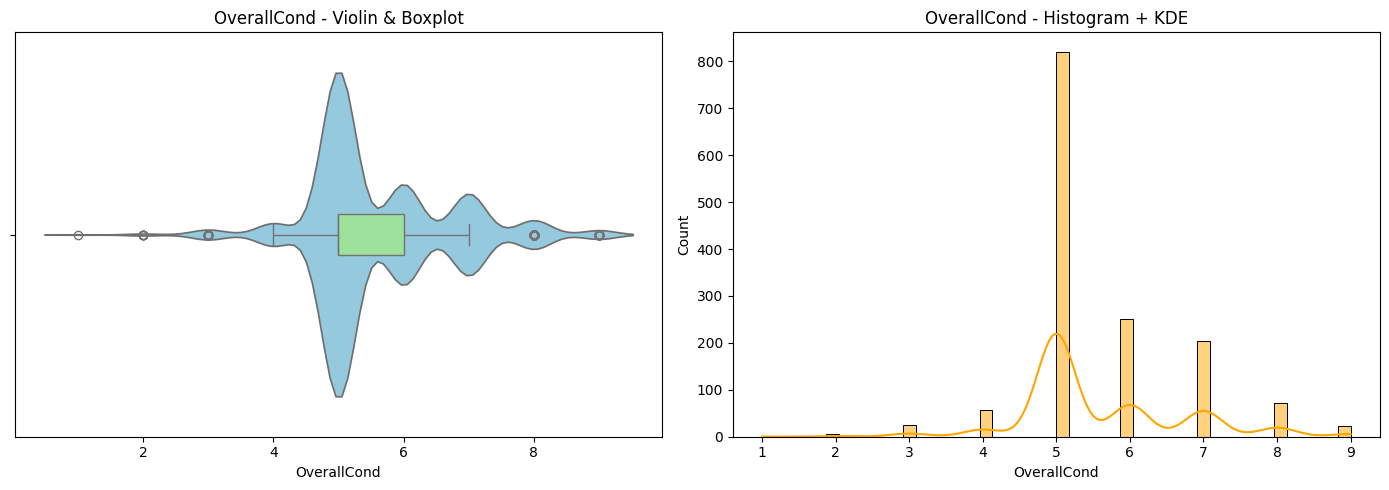

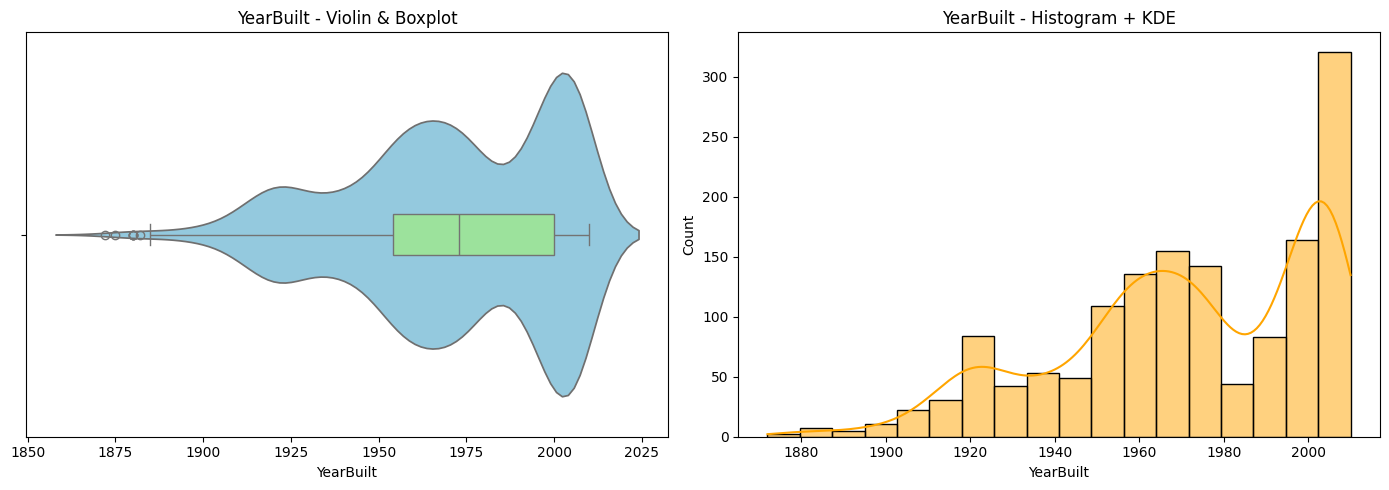

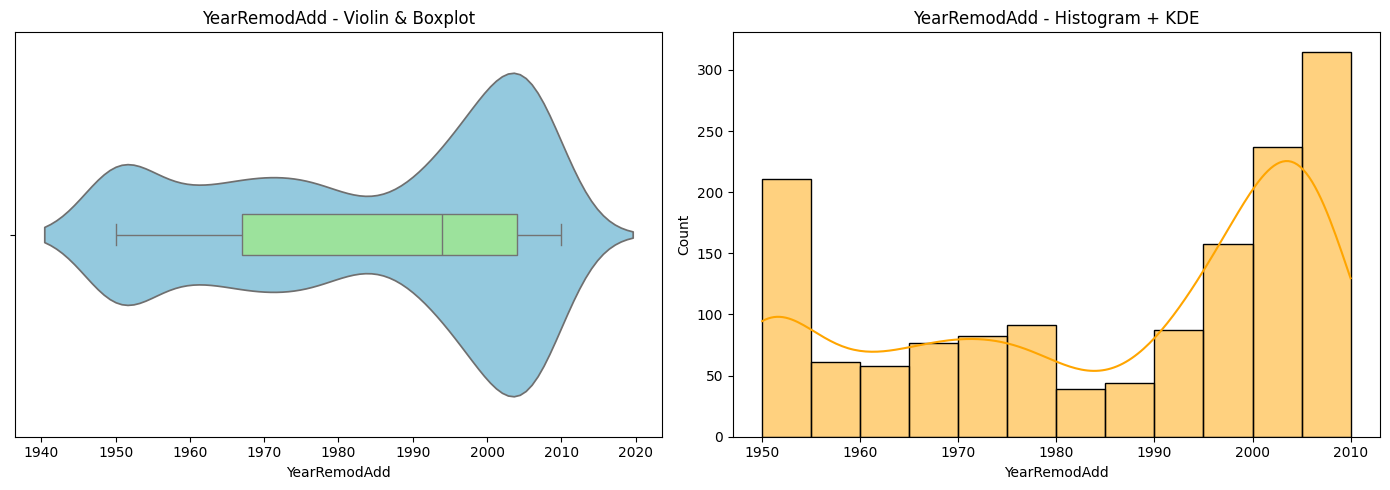

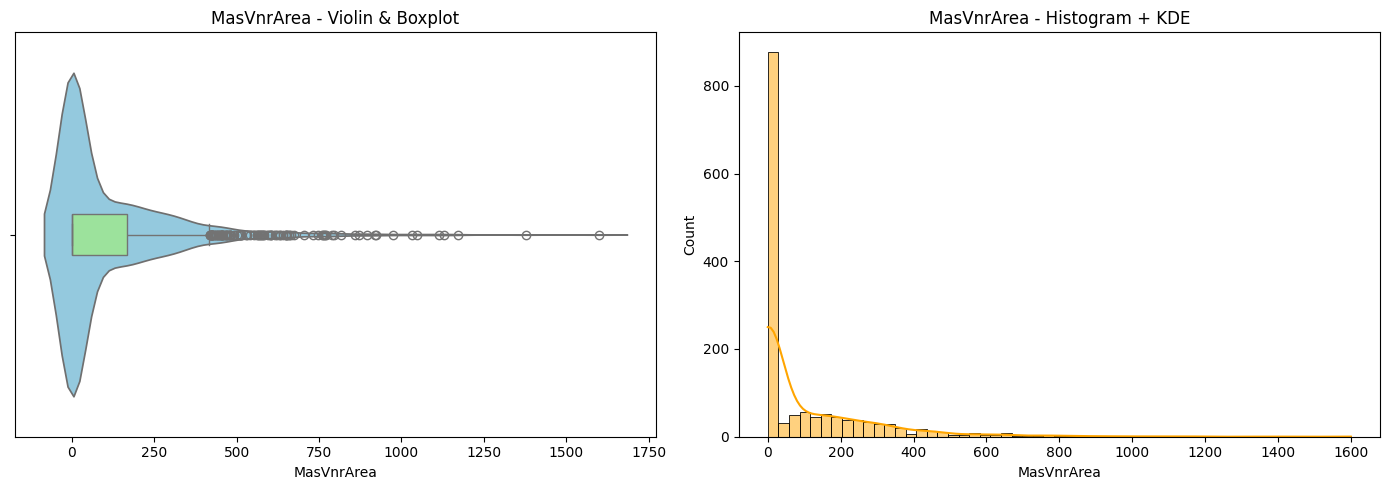

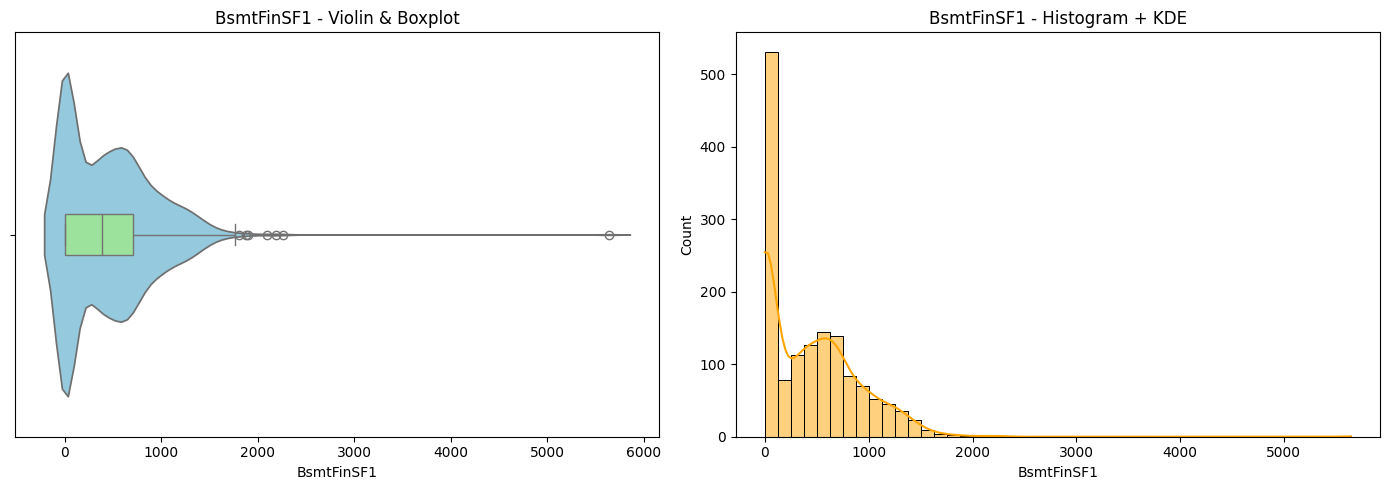

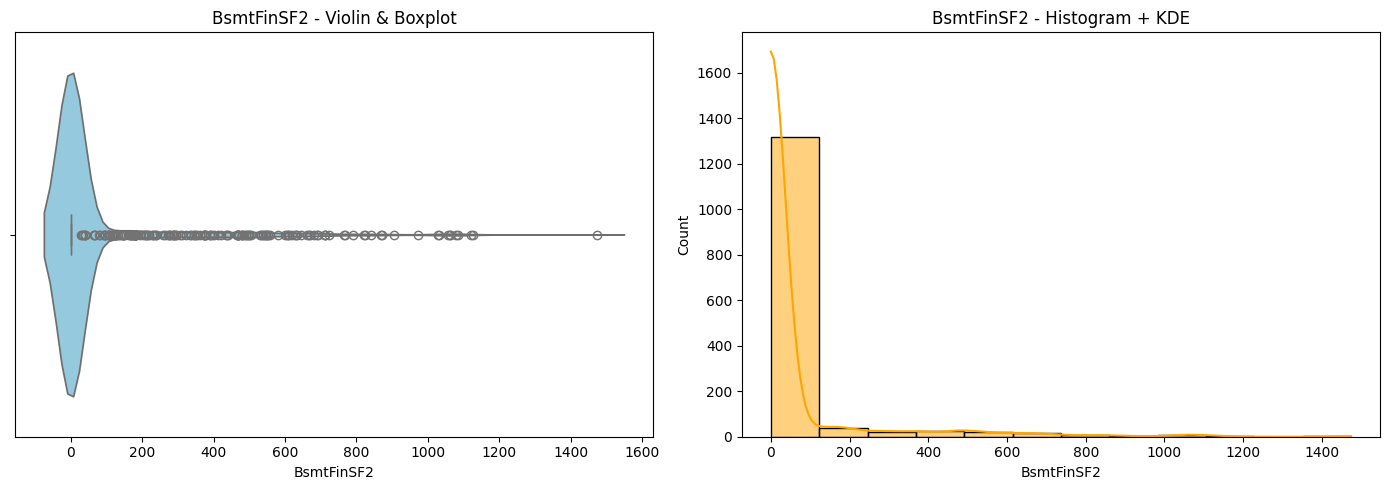

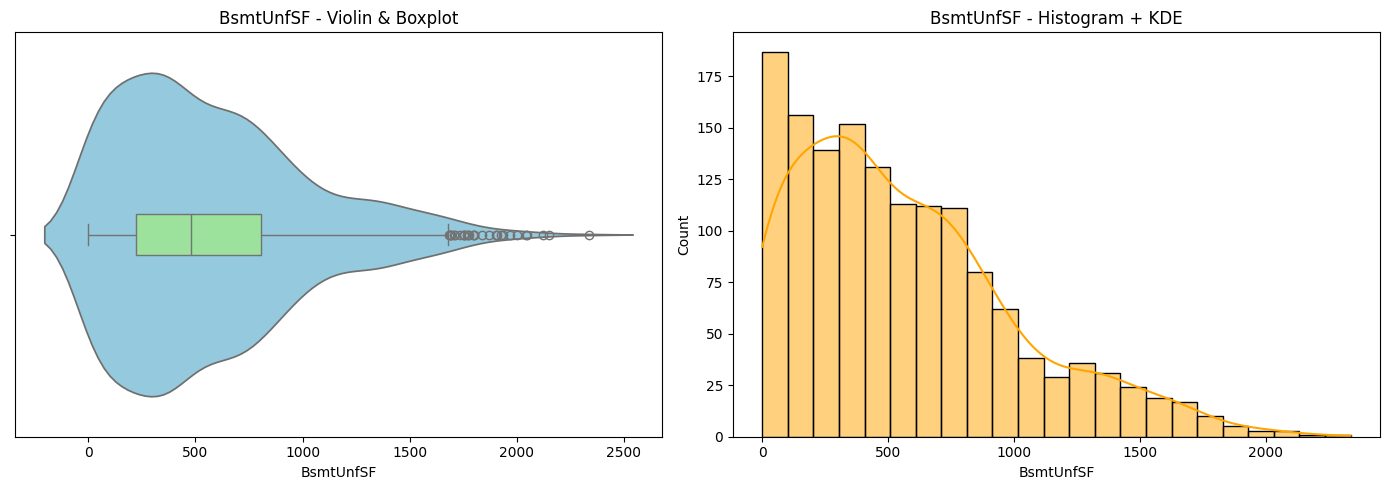

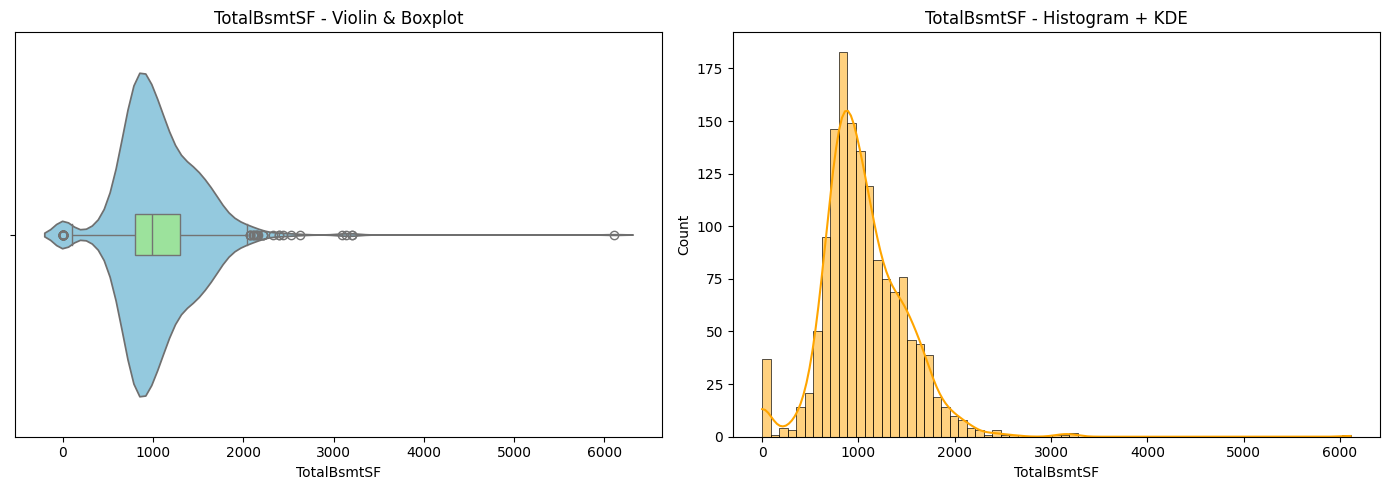

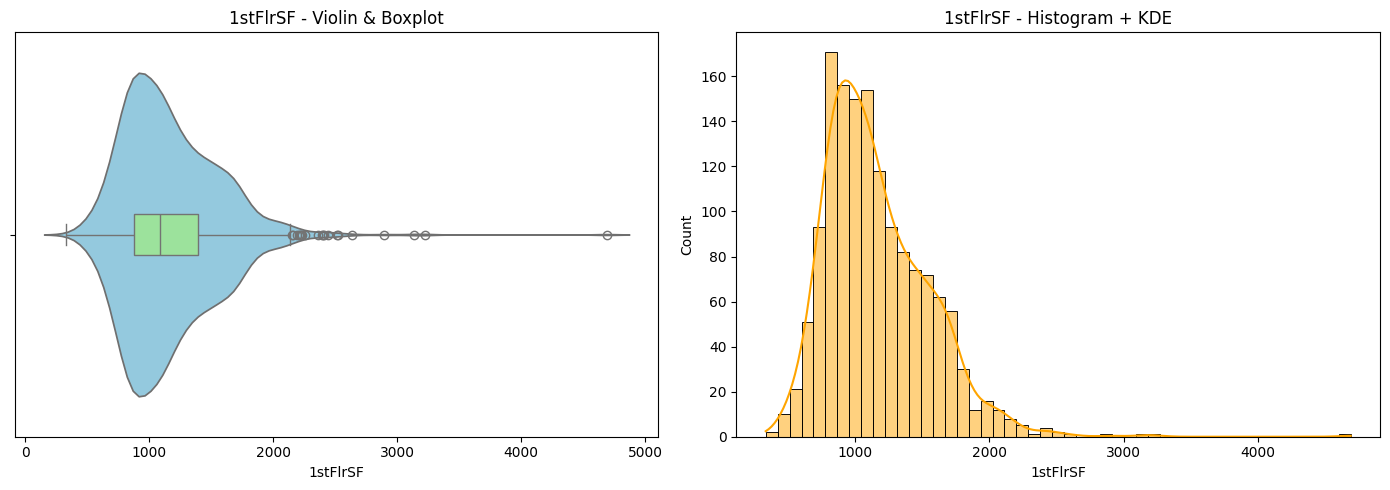

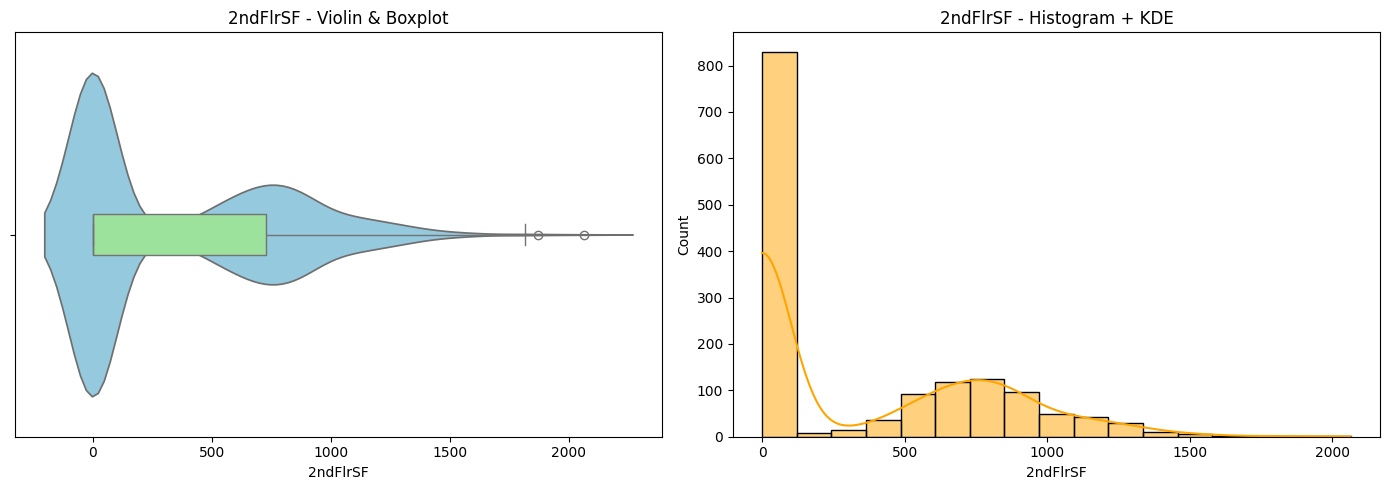

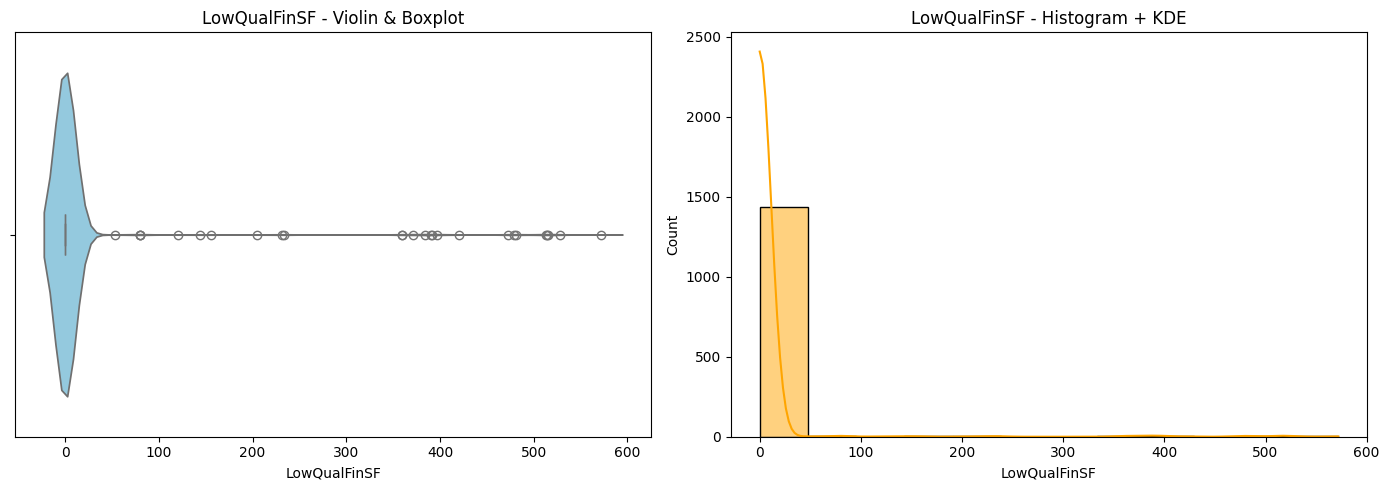

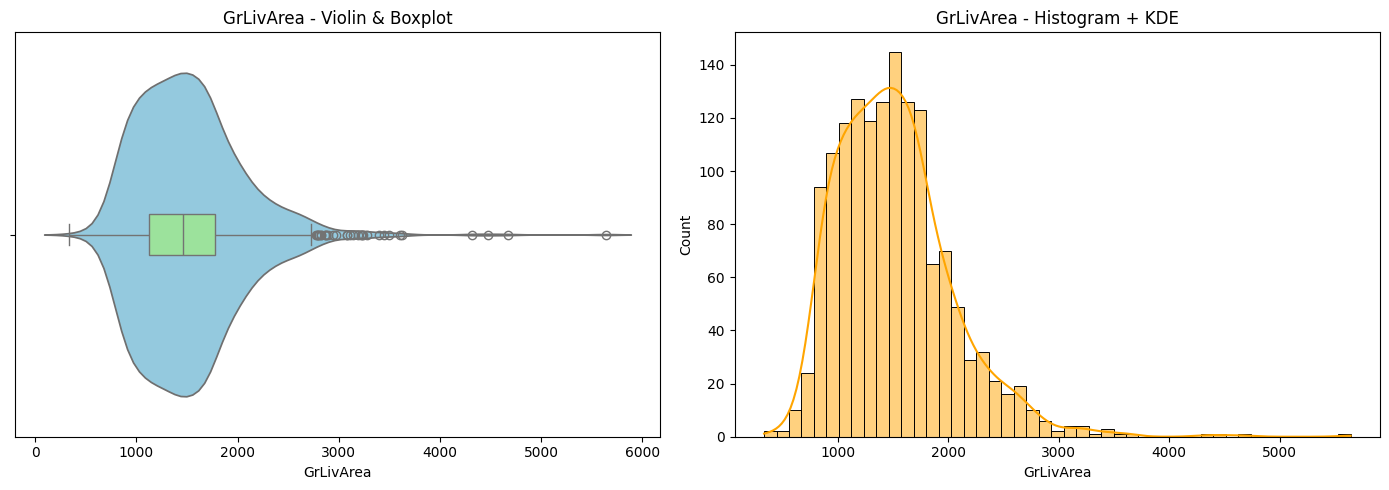

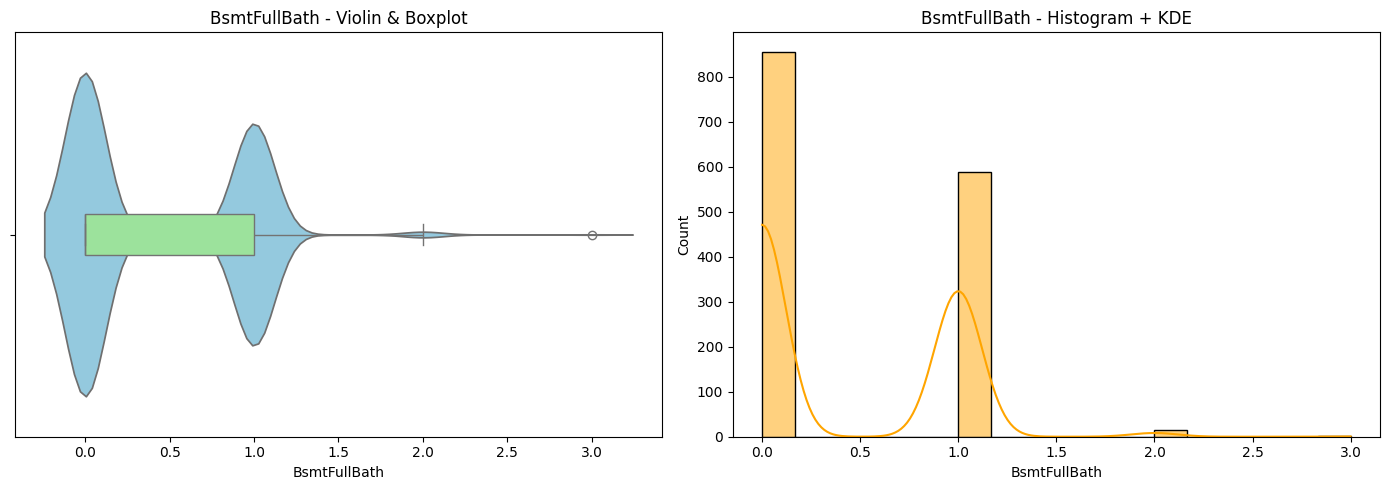

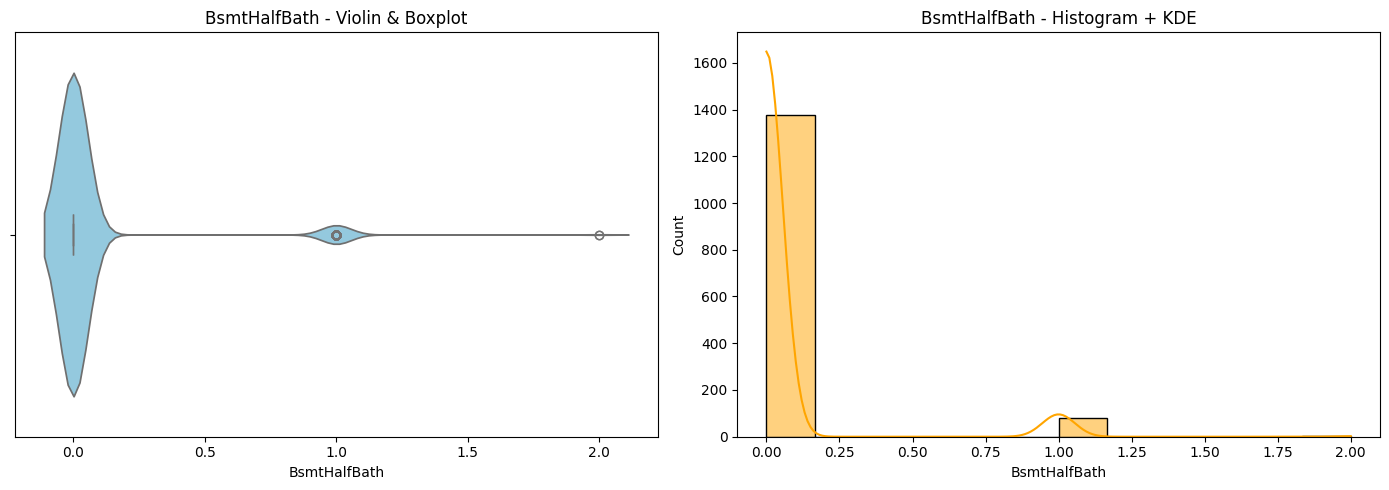

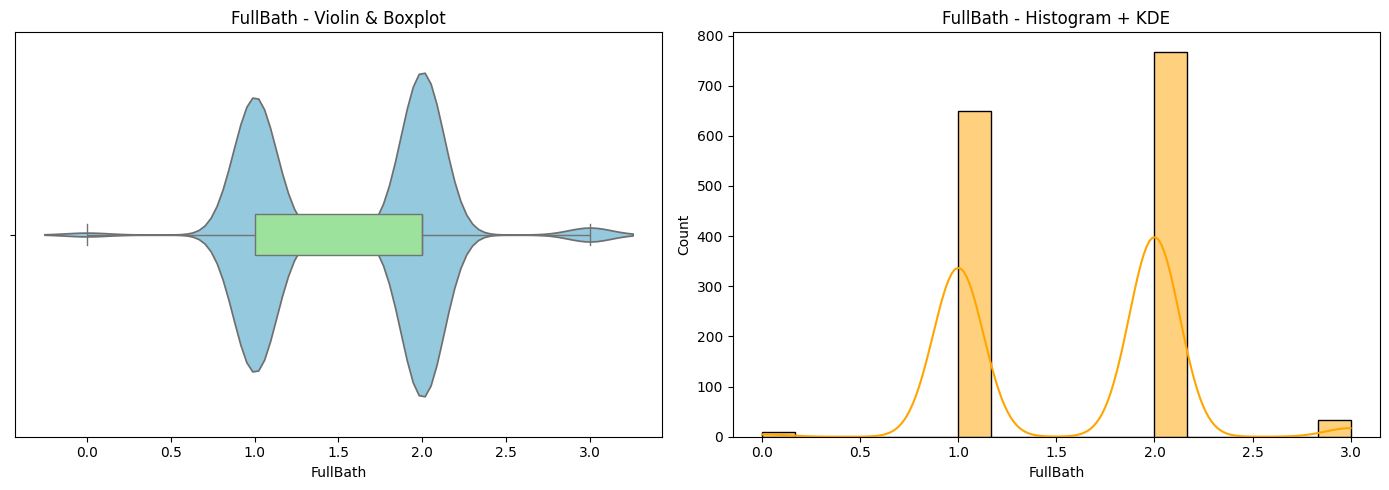

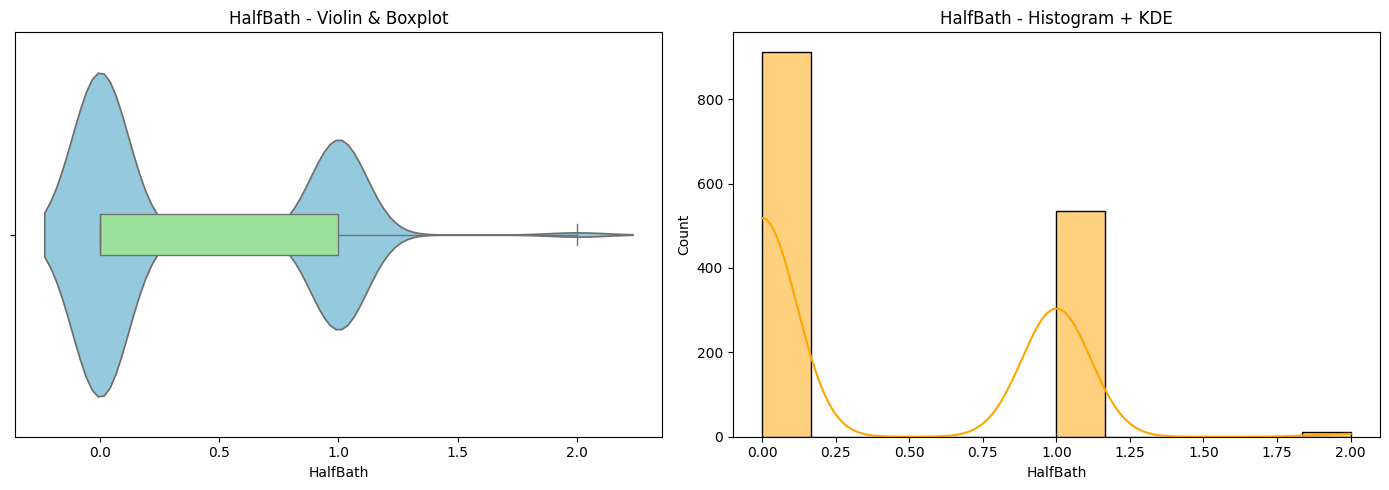

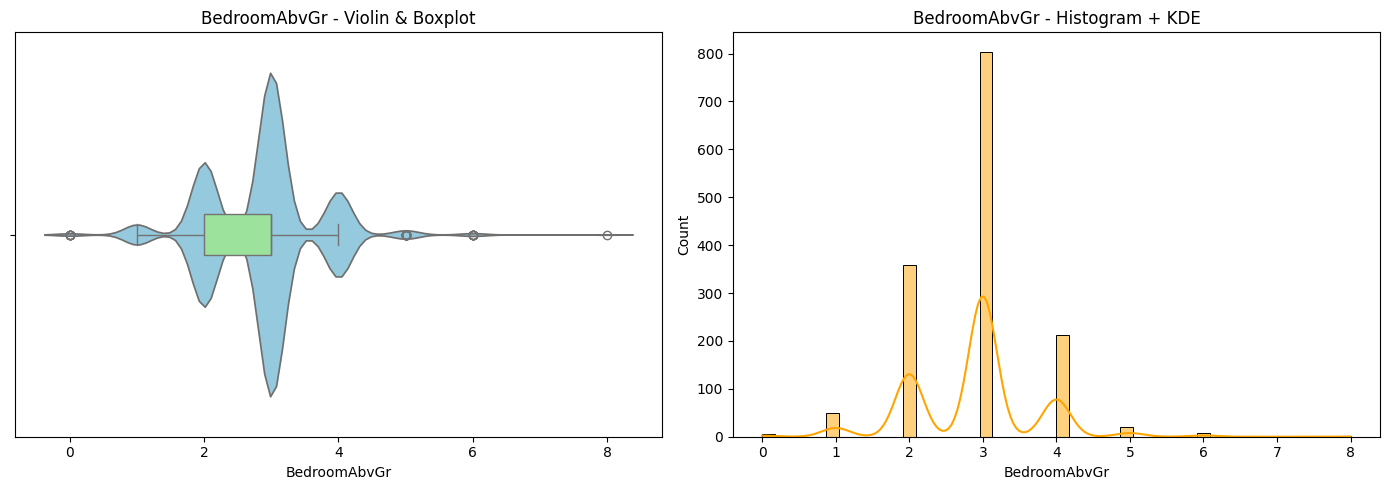

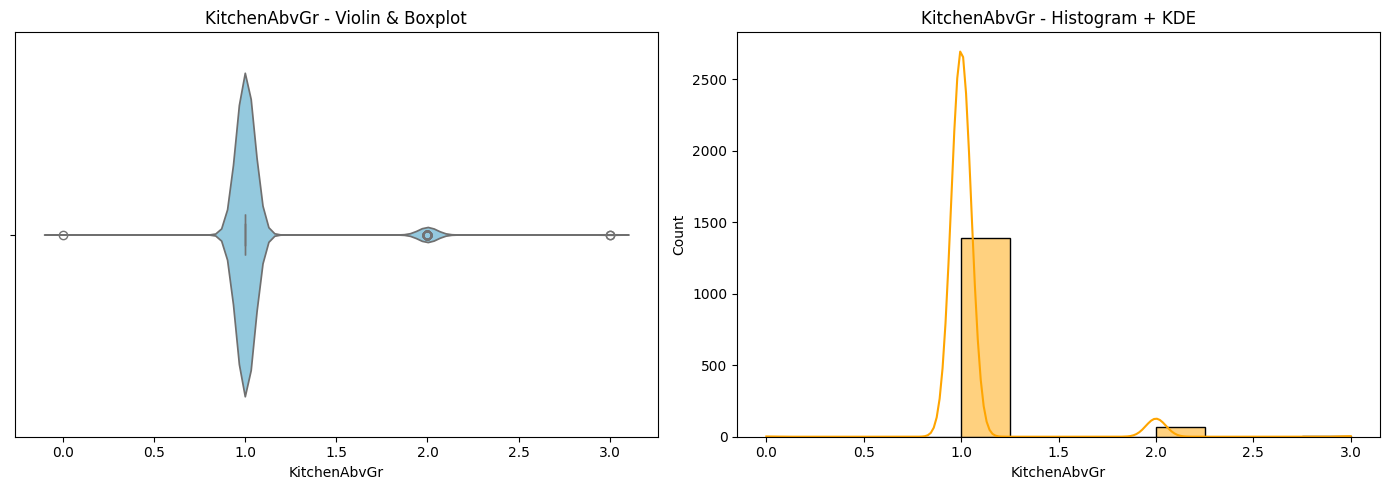

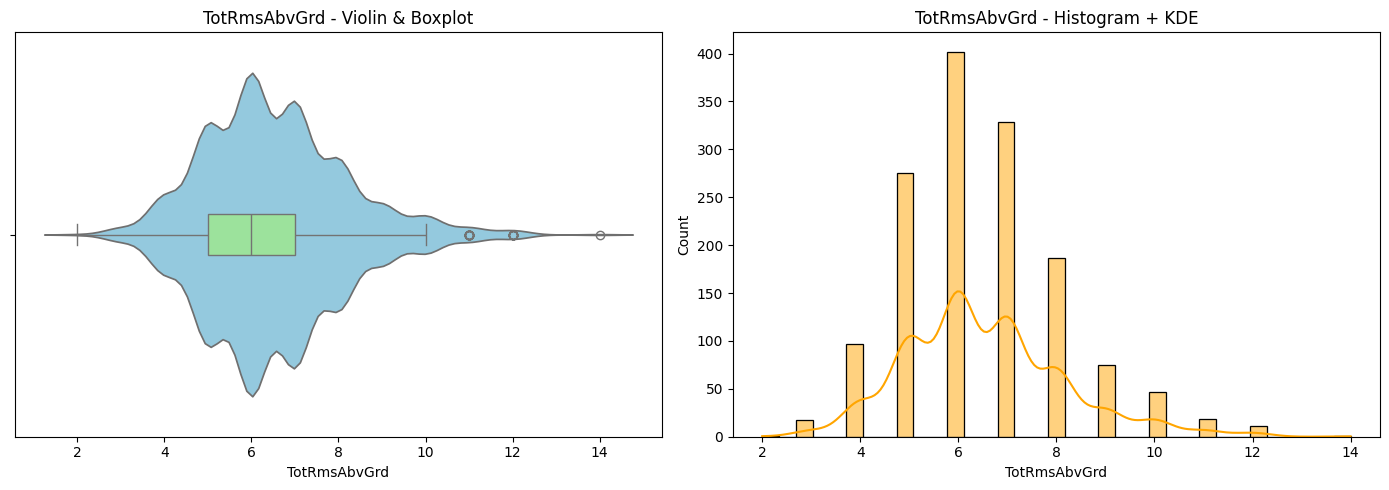

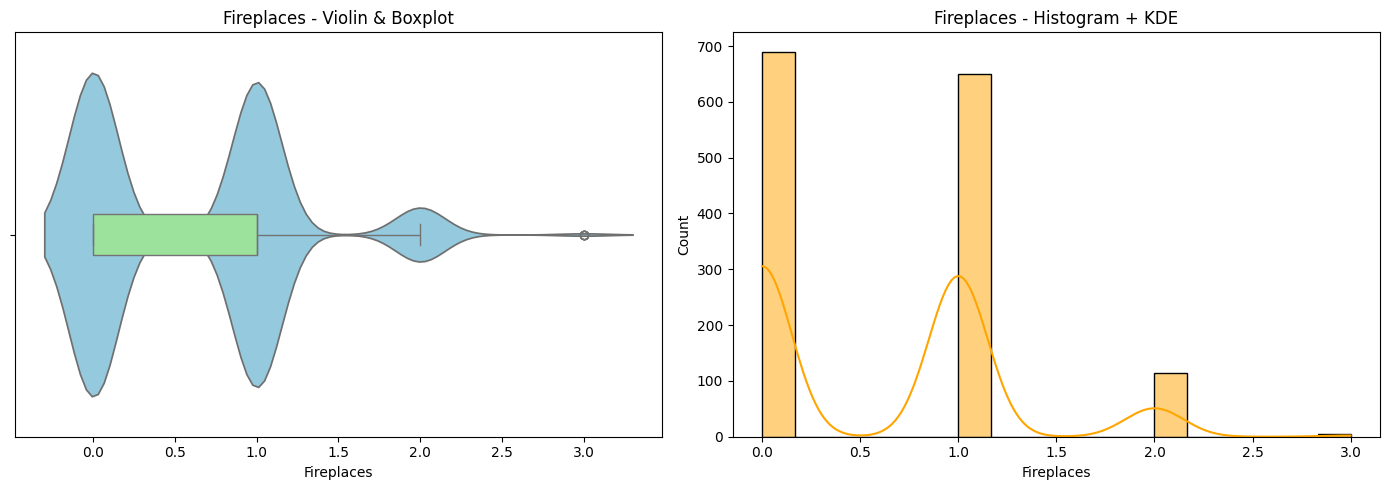

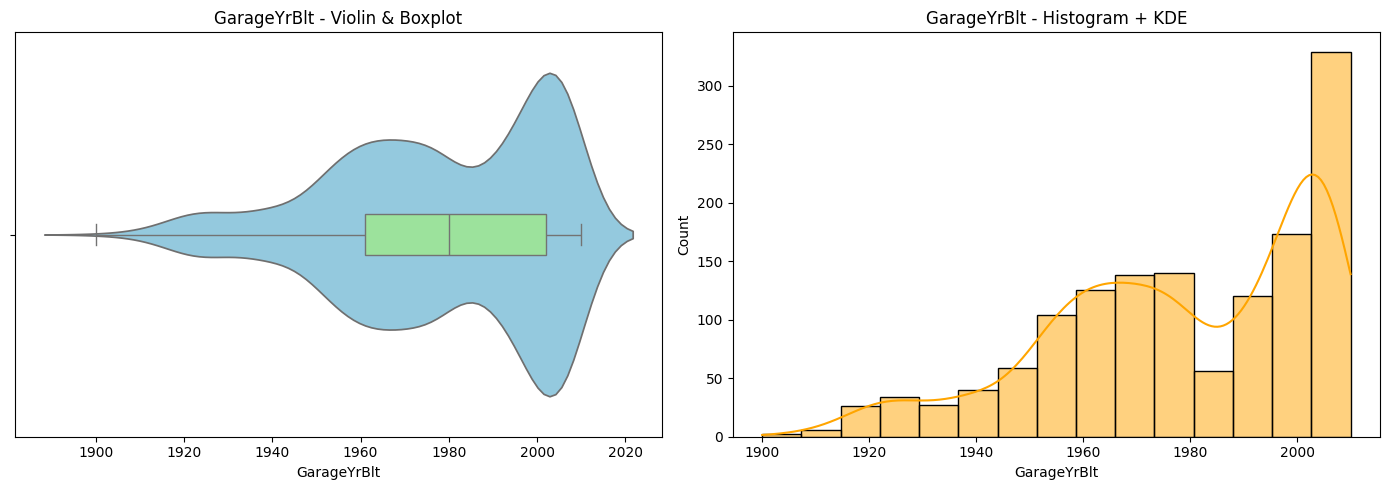

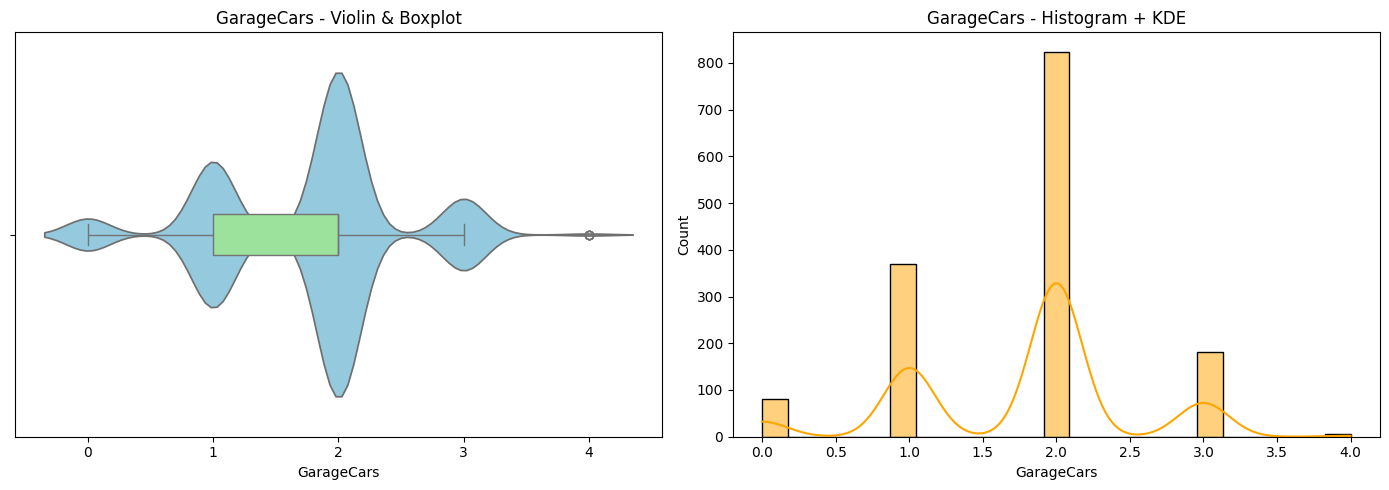

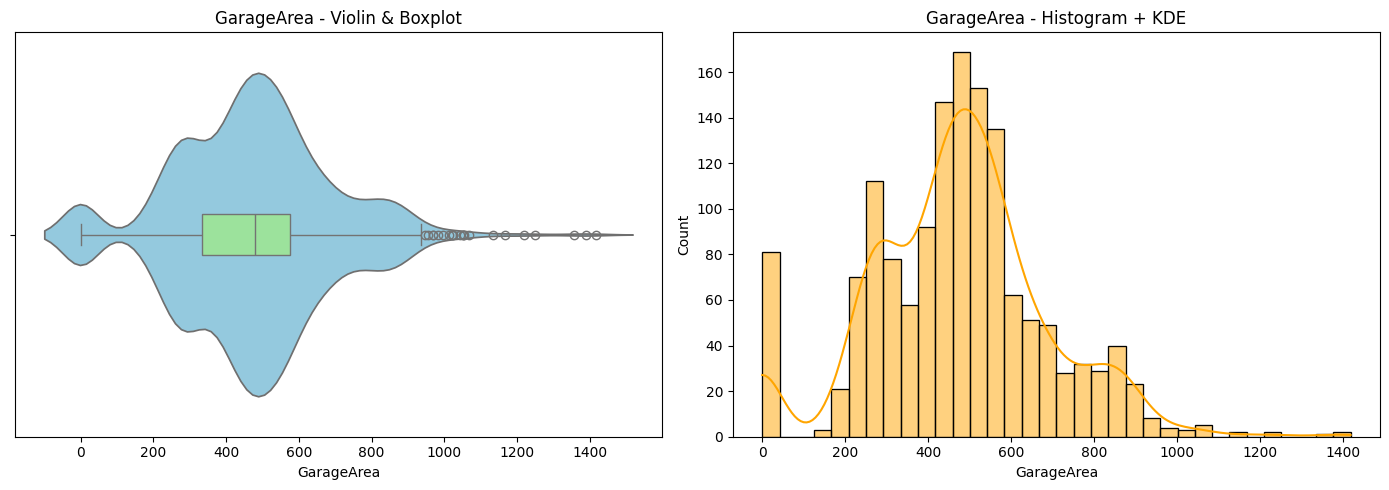

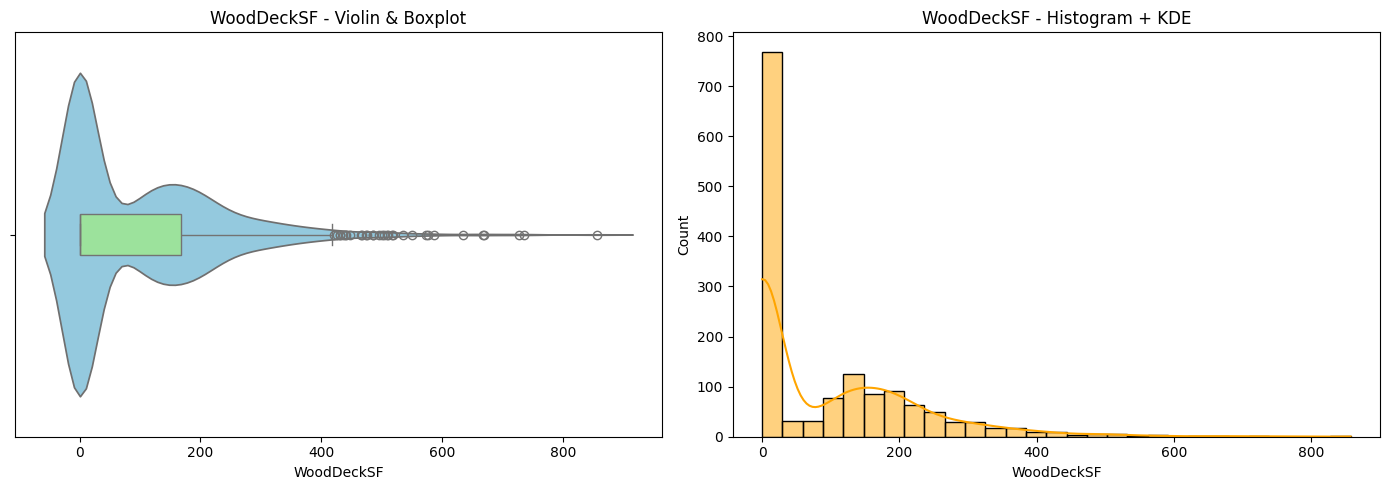

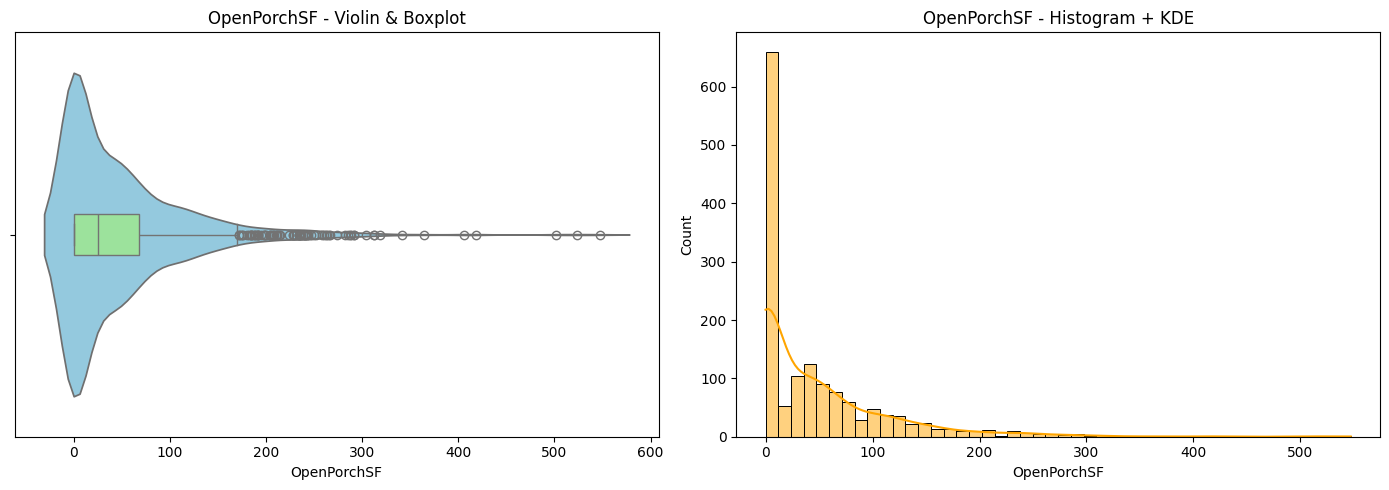

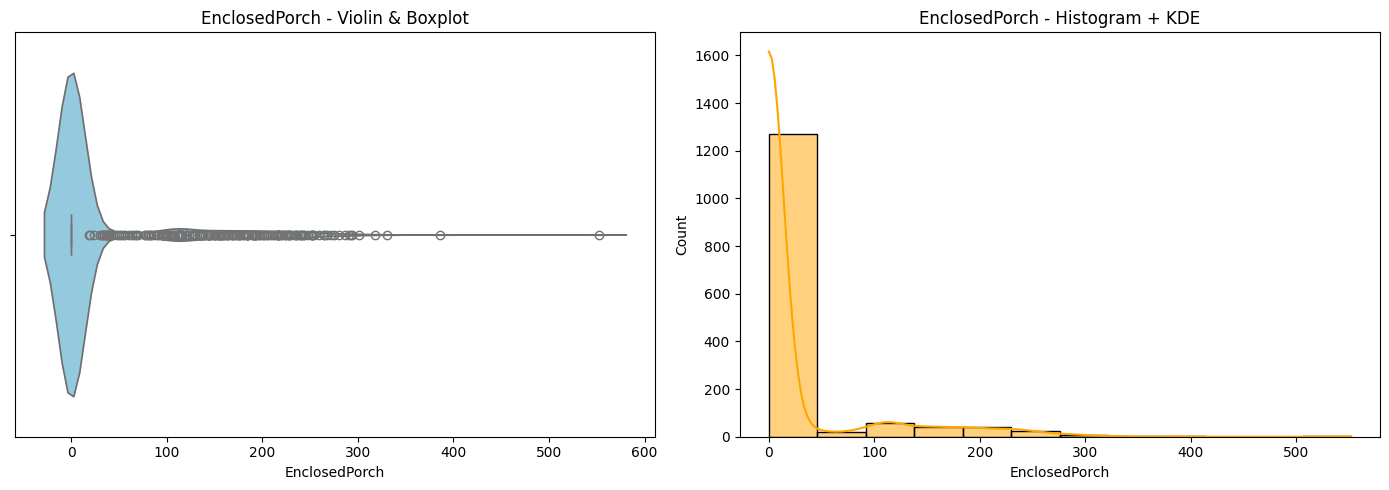

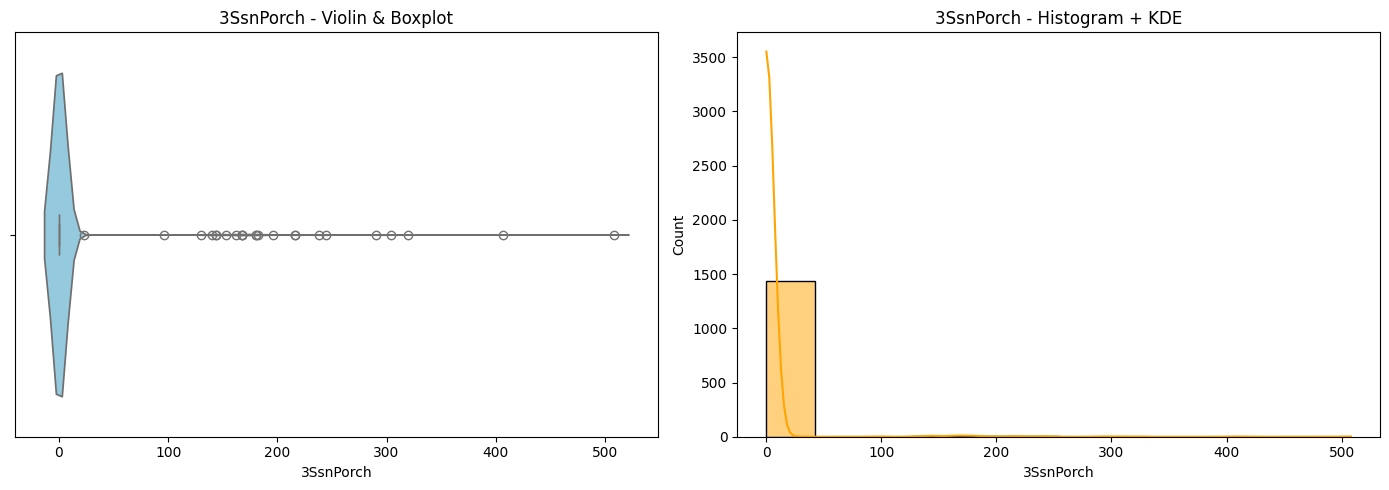

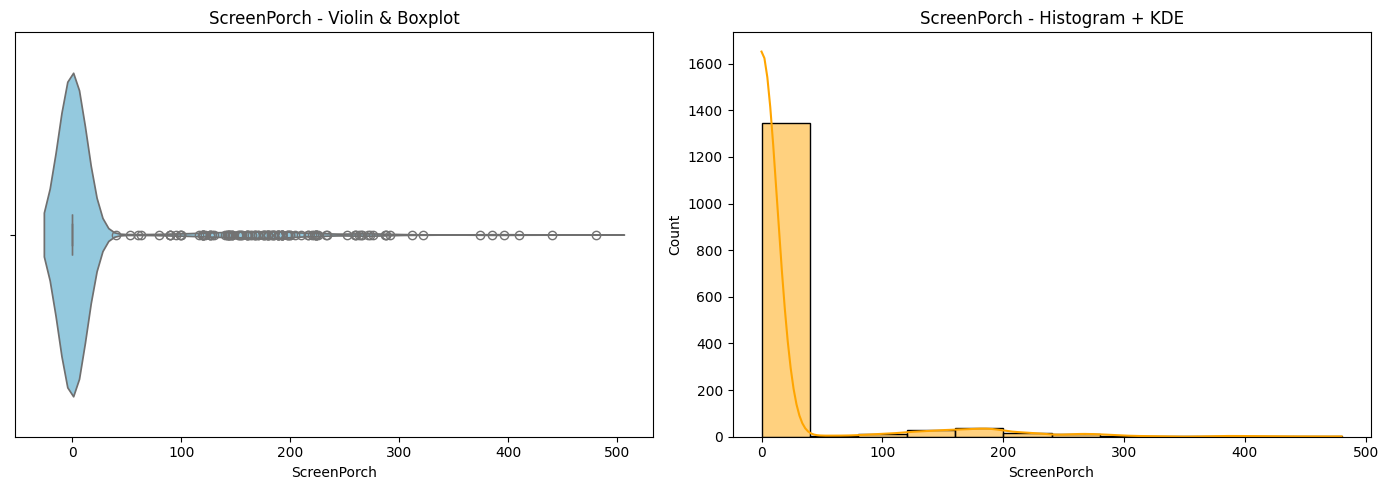

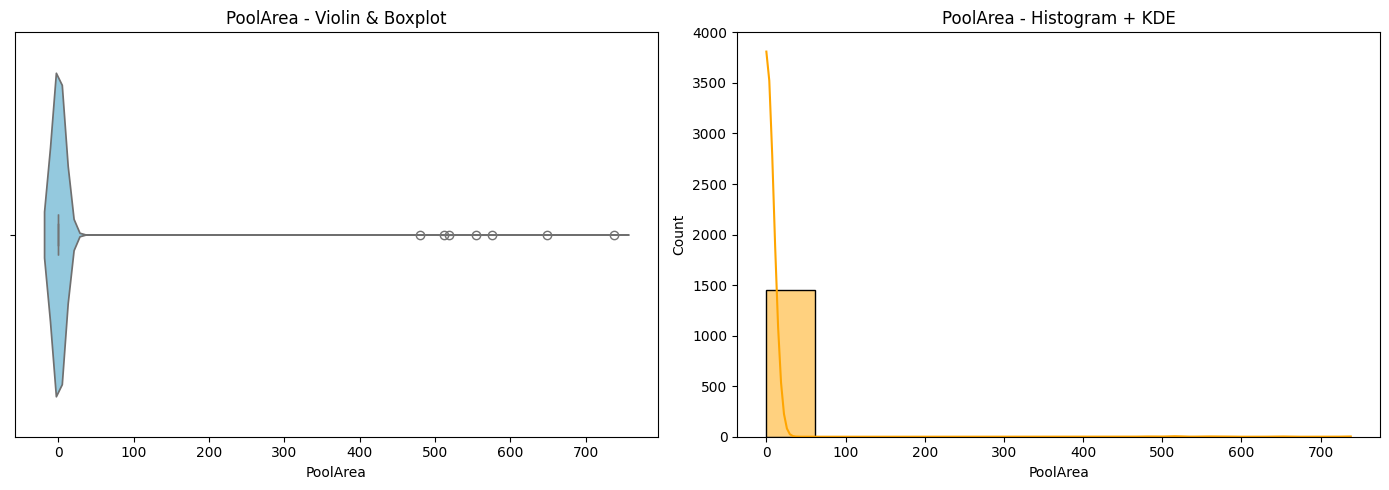

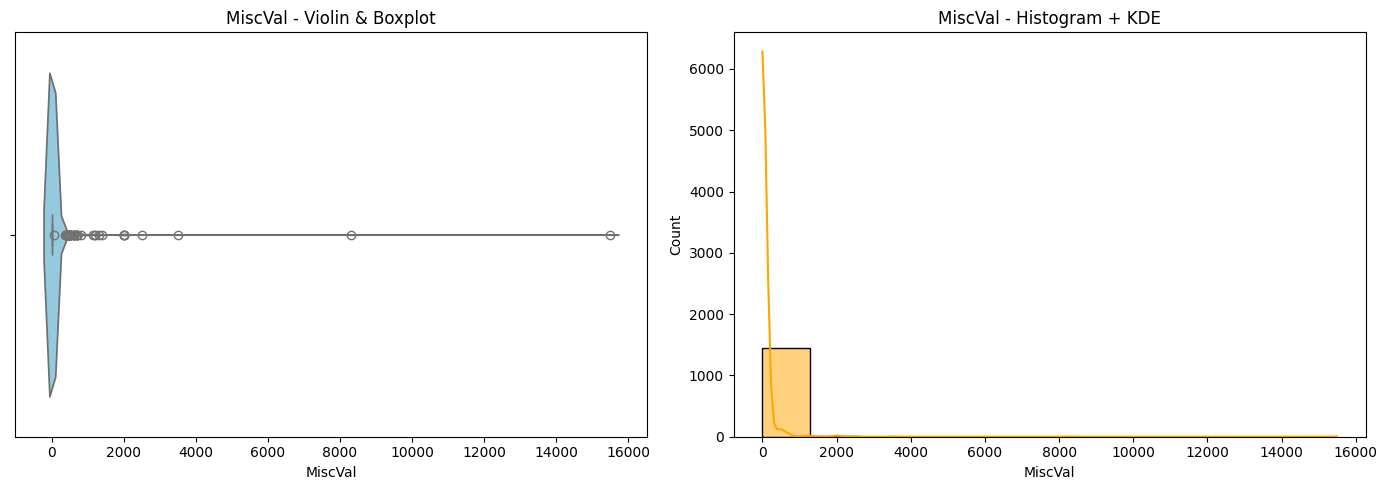

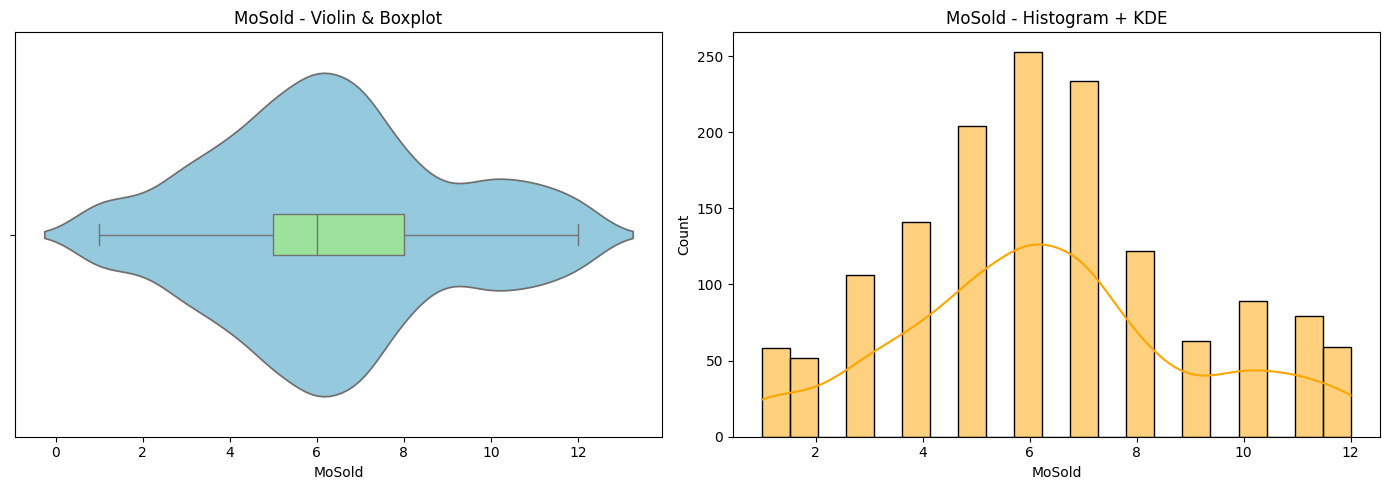

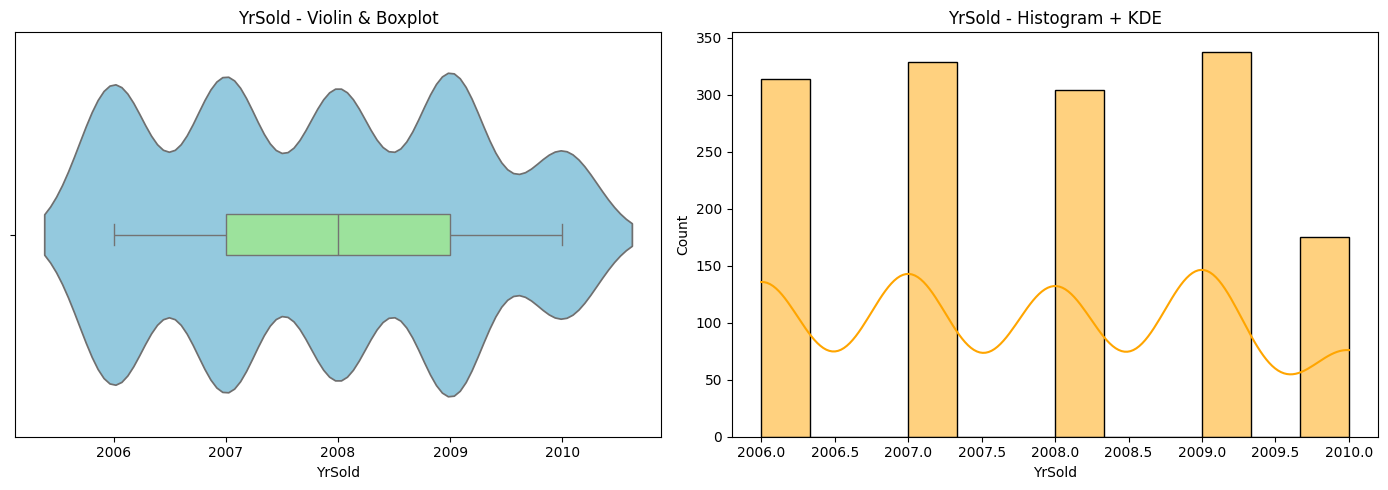

In [44]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    
    sns.violinplot(x=train[col], ax=axes[0], color='skyblue', inner=None)
    sns.boxplot(x=train[col], ax=axes[0], width=0.1, color='lightgreen')
    axes[0].set_title(f'{col} - Violin & Boxplot')

   
    sns.histplot(train[col], kde=True, ax=axes[1], color='orange')
    axes[1].set_title(f'{col} - Histogram + KDE')

    plt.tight_layout()
    plt.show()

In [45]:
cols_to_drop = ['MiscFeature', 'Fence', 'PoolQC', 'Alley', 'MasVnrType', 'FireplaceQu']

for df in [train, test]:
    df.drop(cols_to_drop, axis=1, inplace=True)

In [46]:
from sklearn.impute import KNNImputer

obj_col_msn_train = ['BsmtQual', 'BsmtCond', 'BsmtExposure',
                     'BsmtFinType1', 'BsmtFinType2', 'Electrical']

obj_col_msn_test = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
                    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                    'BsmtFinType2', 'KitchenQual', 'Functional', 'SaleType']

garage_col = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']

 
for df, obj_cols in zip([train, test], [obj_col_msn_train, obj_col_msn_test]):
    
     
    for col in obj_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
    
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    if df[num_cols].isnull().any().any():
        imputer = KNNImputer(n_neighbors=5)
        imputed_array = imputer.fit_transform(df[num_cols])
        df[num_cols] = pd.DataFrame(imputed_array, columns=num_cols, index=df.index)
    
     
    for col in garage_col:
        df[col] = df[col].fillna('NonGarage')

C:\Users\İlyas\AppData\Local\Temp\ipykernel_26720\1525055566.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\İlyas\AppData\Local\Temp\ipykernel_26720\1525055566.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [47]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
 
ordinal_mapping = {
    'LotShape': ['IR3', 'IR2', 'IR1', 'Reg'],
    'LandContour': ['Low', 'HLS', 'Bnk', 'Lvl'],
    'Utilities': ['NoSeWa', 'AllPub'],
    'LandSlope': ['Sev', 'Mod', 'Gtl'],
    'ExterQual': ['Fa', 'TA', 'Gd', 'Ex'],
    'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual': ['Fa', 'TA', 'Gd', 'Ex'],
    'BsmtCond': ['Po', 'Fa', 'TA', 'Gd'],
    'BsmtExposure': ['No', 'Mn', 'Av', 'Gd'],
    'BsmtFinType1': ['Unf', 'LwQ', 'BLQ', 'Rec', 'ALQ', 'GLQ'],
    'BsmtFinType2': ['Unf', 'BLQ', 'ALQ', 'Rec', 'LwQ', 'GLQ'],
    'HeatingQC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual': ['Fa', 'TA', 'Gd', 'Ex'],
    'Functional': ['Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'GarageFinish': ['NonGarage', 'Unf', 'RFn', 'Fin'],
    'GarageQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex', 'NonGarage'],
    'GarageCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex', 'NonGarage'],
    'PavedDrive': ['N', 'P', 'Y']
}

ordinal_cols = list(ordinal_mapping.keys())
ordinal_categories = [ordinal_mapping[col] for col in ordinal_cols]
 
onehot_cols = [
    'MSZoning', 'Street', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2',
    'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition'
]

 
ordinal_enc = OrdinalEncoder(categories=ordinal_categories,
                             handle_unknown='use_encoded_value',
                             unknown_value=-1)

onehot_enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

 
train[ordinal_cols] = ordinal_enc.fit_transform(train[ordinal_cols])

onehot_encoded_train = onehot_enc.fit_transform(train[onehot_cols])
onehot_feature_names = onehot_enc.get_feature_names_out(onehot_cols)
onehot_df_train = pd.DataFrame(onehot_encoded_train, columns=onehot_feature_names, index=train.index)

train.drop(columns=onehot_cols, inplace=True)
train = pd.concat([train, onehot_df_train], axis=1)

 
test[ordinal_cols] = ordinal_enc.transform(test[ordinal_cols])

onehot_encoded_test = onehot_enc.transform(test[onehot_cols])
onehot_df_test = pd.DataFrame(onehot_encoded_test, columns=onehot_feature_names, index=test.index)

test.drop(columns=onehot_cols, inplace=True)
test = pd.concat([test, onehot_df_test], axis=1)

In [48]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

train = scaler.fit_transform(train)
test = scaler.transform(test)

In [49]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from  xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'randomforest': RandomForestRegressor(random_state=42),
    'gradientboosting' : GradientBoostingRegressor(random_state=42),
    'xgboost' : XGBRegressor(random_state=42, eval_metric='rmse'),
    'lightgbm' : LGBMRegressor(random_state=42, verbose=-1),
    'catboost' : CatBoostRegressor(random_state=42, verbose=False),
    'lr' : LinearRegression(),
    'ridge' : Ridge(alpha=5.0),
    'lasso' : Lasso(alpha=0.0005, max_iter=1000),
    'elasticnet' : ElasticNet(alpha=0.0005, l1_ratio=0.5, max_iter=1000),
    'svm' : SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

X = train
y = y

results = []

for name, model in models.items():
    rmses = []
    maes = []
    r2s = []
     
    
    for train_index, val_index in kfold.split(X):
        X_train_fold, X_val_fold = X[train_index], X[val_index]
        y_train_fold, y_val_fold = y[train_index], y[val_index]

        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_val_fold)
        
        rmse = np.sqrt(mean_squared_error(y_val_fold, preds))
        mae = mean_absolute_error(y_val_fold, preds)
        r2 = r2_score(y_val_fold, preds)
        
        rmses.append(rmse)
        maes.append(mae)
        r2s.append(r2)
        
         
    
    results.append({
        'Model': name,
        'RMSE': np.mean(rmses),
        'MAE': np.mean(maes),
        'R2': np.mean(r2s)
    })
 
results_df = pd.DataFrame(results)
print("\nModel Karşılaştırma Tablosu:")
print(results_df)

c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\İlyas\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserW


Model Karşılaştırma Tablosu:
              Model      RMSE       MAE        R2
0      randomforest  0.144832  0.096401  0.863654
1  gradientboosting  0.133397  0.088035  0.883712
2           xgboost  0.145211  0.095156  0.863050
3          lightgbm  0.135461  0.090462  0.881114
4          catboost  0.123028  0.080033  0.901313
5                lr  0.146297  0.086579  0.850324
6             ridge  0.143798  0.088417  0.854557
7             lasso  0.139408  0.084242  0.860449
8        elasticnet  0.140138  0.084835  0.859695
9               svm  0.361262  0.276627  0.177125


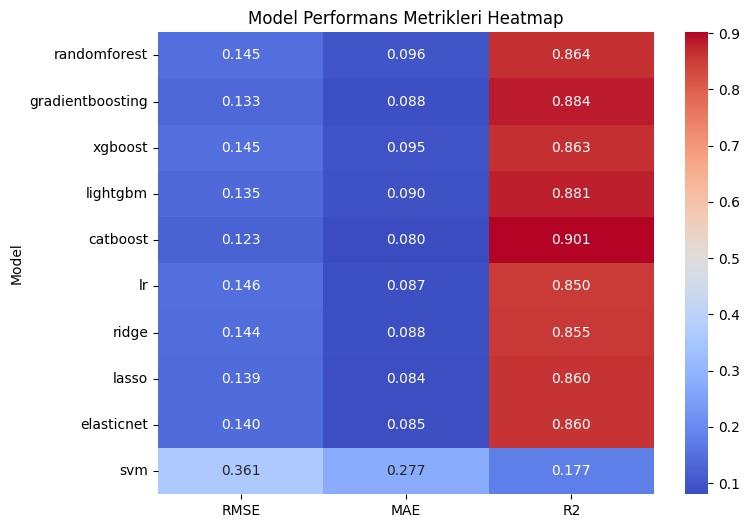

In [50]:
heatmap_data = results_df.set_index('Model')[['RMSE', 'MAE', 'R2']]

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Model Performans Metrikleri Heatmap')
plt.show()